# Dataset

In this notebook, we are exploring the dataset used for the vehicle localization assigment. The provided files are in the Point Cloud Data (PCD) format, which are crucial for processing and visualizing spatial data in autonomous vehicle technology.

## Files Included

- **map.pcd:** This file represents the map where the vehicle needs to localize itself.
- **frames/frames_\<n\>.pcd:** This directory contains sequential frames from 0 to 1013, capturing different moments and perspectives of the vehicle's journey inside the CARLA simulator.
- **ground_truth:** This file contains the exact vehicle positions in meters and orientations in radians for each frame from 0 to 1013. It serves as a reference to evaluate the vehicle's localization accuracy.

## Ground Truth Analysis

### Load ground truth values

To handle and visualize the ground truth data efficiently, we will use various Python libraries. These libraries will help in loading, processing, and plotting the data for better analysis.

In [17]:
import os

import matplotlib.pyplot as plt
import numpy as np
import open3d as o3d
import pandas as pd

from pypcd4 import PointCloud
from scipy.spatial.transform import Rotation
from typing import List, Tuple


# Load ground truths
gts = pd.read_csv("./dataset/ground_truth.csv")

# Print gt
print(gts)

      Frame        x        y         z      roll     pitch       yaw
0         0    0.000  0.00000  0.000000  0.000000  0.000000  0.000000
1         1    0.000  0.00000  0.015636  0.000000  0.000000  0.000000
2         2    0.000  0.00000  0.005846  0.000000  0.000000  0.000000
3         3    0.000  0.00000  0.005628  0.000000  0.000000  0.000000
4         4    0.000  0.00000  0.005628  0.000000  0.000000  0.000000
...     ...      ...      ...       ...       ...       ...       ...
1009   1009  182.299  5.29271 -0.018730 -0.029093 -0.014225  0.019378
1010   1010  182.299  5.27850 -0.023267 -0.030727 -0.015000  0.019204
1011   1011  182.299  5.28007 -0.014406 -0.028470 -0.012781  0.019203
1012   1012  182.299  5.27980 -0.023047 -0.035554 -0.017184  0.019364
1013   1013  182.299  5.28085 -0.024493 -0.030387       NaN       NaN

[1014 rows x 7 columns]


You can easily retrieve the vehicle's position and orientation using pandas with the following approach:

In [19]:

# Get position and orientation for a specific frame
FRAME = 50
gt = gts.iloc[FRAME]

# Extract the row and use direct slicing to create numpy arrays
gt = gts.iloc[FRAME]
pos = gt[[' x', ' y', ' z']].to_numpy()
orientation = gt[[' roll', ' pitch', ' yaw']].to_numpy()

# Print position and orientation arrays
print(f"Position: {pos}")
print(f"Orientation: {orientation}")


Position: [4.28331    0.0609112  0.00704979]
Orientation: [-4.26106e-06 -8.84533e-05  4.61252e-04]


#### Calculate error

For this assigment you need to calculate the error between the localization and the ground truth values. You can calculate two types of errors by comparing the ground truth data with estimated values:

1. **Lateral Error**: Measures the deviation between the ground truth and estimated positions in the XY plane.
   
2. **Yaw Angle Error**: Determines the difference between the ground truth and estimated orientations in the yaw angle.

The following function computes these errors given ground truth and estimated positions/orientations:

In [20]:
def calc_error(gt_position: np.ndarray, gt_orientation: List[float], estimated_position: np.ndarray, estimated_orientation: np.ndarray) -> Tuple[float, float]:
    """
    Calculates lateral error and yaw angle error based on ground truth and estimated values.

    Args:
    - gt_position (np.ndarray): Ground truth displacements in [x, y, z] format.
    - gt_orientation (List[float]): Ground truth angles in [roll, pitch, yaw] format.
    - estimated_position (np.ndarray): Estimated displacements in [x, y, z] format.
    - estimated_orientation (np.ndarray): Estimated angles in [roll, pitch, yaw] format.

    Returns:
    - Tuple[float, float]: Lateral error in meters and yaw angle error in degrees.
    """
    if not (gt_position.shape == (3,) and estimated_position.shape == (3,)):
        raise ValueError("Position inputs should be 1D numpy arrays with 3 elements [x, y, z].")

    if not (len(gt_orientation) == 3 and len(estimated_orientation) == 3):
        raise ValueError("Orientation inputs should be a list of 3 elements [roll, pitch, yaw] and a 3x3 rotation matrix.")

    # Calculate lateral error in the XY plane
    position_error = np.linalg.norm(estimated_position[:2] - gt_position[:2])

    # Calculate yaw angle error in degrees
    yaw_error = gt_orientation[2] - estimated_orientation[2]

    return position_error, yaw_error


# Sim estimations
t_estimated = np.array([[10],
              [5],
              [0]])

yaw = 45
R_estimated = Rotation.from_euler("z", yaw, degrees=True).as_matrix() 

# Transform to position and orientation
estimated_pos = t_estimated.flatten()
estimated_orientation = Rotation.from_matrix(R_estimated).as_euler("xyz")

# Calculate errors

pos_error, yaw_error = calc_error(pos, orientation, estimated_pos, estimated_orientation)

# Print position and orientation arrays
print(f"GT Position: {pos}")
print(f"GT Orientation: {orientation}\n")

print(f"Estimated Position: {estimated_pos}")
print(f"Estimated Orientation: {estimated_orientation}\n")

print(f"Position Error: {pos_error}")
print(f"Position Error: {yaw_error}")

GT Position: [4.28331    0.0609112  0.00704979]
GT Orientation: [-4.26106e-06 -8.84533e-05  4.61252e-04]

Estimated Position: [10  5  0]
Estimated Orientation: [0.         0.         0.78539816]

Position Error: 7.554809245135541
Position Error: -0.7849369113974484


## Working with PCD files

In this assignment, you will also work with point clouds representing 3D environments. This section provides useful resources for processing these point clouds effectively.


### Load PCD files

As explored in the Sensor Fusion assignment, one of the primary formats for storing point cloud data is the PCD (Point Cloud Data) format. The dataset for this project contains files exclusively in this format, so we'll need to load these files into our programs efficiently.

For this purpose, we'll use the `pypcd4` library and create a custom function to load point cloud data (PCDs).

In [21]:
def pcd_from_path(file_path: str) -> np.ndarray:
    """
    Loads point clouds from PCD files using the PointCloud library (assumed to be open3d or similar).

    Parameters:
        file_path (str): Path to a .pcd file.

    Returns:
        np.ndarray: Numpy array representing the point cloud, shape [n_points, m_channels].
    
    Raises:
        ValueError: If the file format is not 'pcd'.
        FileNotFoundError: If the file does not exist.
    """
    if not file_path.endswith(".pcd"):
        raise ValueError('Only ".pcd" format is accepted.')
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"The file {file_path} does not exist.")
    
    pc = PointCloud.from_path(file_path)
    return pc.numpy()


# Load the map and frame data as point clouds
map_array = pcd_from_path("./dataset/map.pcd") 
pointcloud_array = pcd_from_path("./dataset/frames/frame_0.pcd")

### Visualizing PCD Data

Visualizing point cloud data is crucial for understanding the spatial relationships and structures within the data, which is particularly important in applications such as autonomous vehicle navigation.

#### 2D Visualization of Point Clouds

Iniatlly, it's often useful to represent point cloud data in a 2D plot. This can help in quickly analyzing the data's general spatial distribution and provide an easily interpretable visualization for debugging or exploring specific regions. The following function demonstrates how to plot point cloud data in 2D using Matplotlib. As you can see we are ploting the data from a Bird Eye View perspective.

In [22]:
def plot_pcd(ax: plt.Axes, points: np.ndarray, **kwargs):
    """
    Plots point cloud data on a given matplotlib axis.

    Parameters:
        ax (matplotlib.axes.Axes): The axes on which to plot the point cloud.
        points (np.ndarray): The point cloud data, expected shape [n_points, at least 2].
        **kwargs: Additional keyword arguments passed to matplotlib scatter plot.

    Raises:
        ValueError: If 'points' does not have the correct dimensions.
    """
    if points.ndim < 2 or points.shape[1] < 2:
        raise ValueError("The 'points' array must have at least two dimensions [n_points, at least 2].")

    return ax.scatter(points[:, 0], points[:, 1], **kwargs)

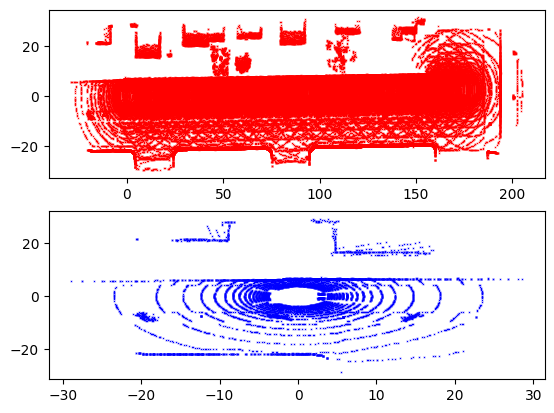

In [23]:
fig, (ax1,ax2) = plt.subplots(2,1)

plot_pcd(ax1, map_array, color="red", label="Target", marker='x',s=.10)
plot_pcd(ax2, pointcloud_array, color="blue", label="Source", marker='x',s=.10)

plt.show()

#### 3D Visualization of Point Clouds

To effectively analyze the 3D structure of the environment captured in PCD files, we'll use a Python function to render the point clouds in a 3D space. This visualization helps to have a grasp on how the pointcloud is structured. For this we will rely on the `open3d` library that has several tools to work with pointclouds in python. 

In [24]:
def show_pcl(pcl: np.ndarray):
    
    pointcloud = o3d.geometry.PointCloud()
    pointcloud.points = o3d.utility.Vector3dVector(pcl[:,:3])

    vis = o3d.visualization.Visualizer()
    vis.create_window()
    vis.add_geometry(pointcloud)
    
    opt = vis.get_render_option()
    opt.background_color = (0, 0, 0)
    opt.point_size = 2

    vis.run()
    vis.destroy_window()
    del opt  # Delete to avoid having  [Open3D ERROR] GLFW Error: The GLFW library is not initialized
    del vis  # Delete to avoid having  [Open3D ERROR] GLFW Error: The GLFW library is not initialized

In [25]:
# Example of how to visualize the map and a frame
#### Map Visualization
show_pcl(map_array)


In [26]:
#### Frame Visualization
show_pcl(pointcloud_array)

### Downsample poincloud

When analyzing the map and frame point clouds, it's evident that these data arrays consist of an immense number of individual points. This high density can significantly increase computation time and lead to unstable results during processing. To address these challenges, downsampling is an essential step in point cloud processing that aims to reduce the density of the points while maintaining the overall structural integrity.

#### Importance of Downsampling:

1. **Improved Computation Time:** High-density point clouds are computationally intensive, especially in tasks like registration (aligning point clouds). Downsampling simplifies the data, leading to faster processing.

2. **Stability in Analysis:** Excessive points may introduce noise and outliers into the data, resulting in inconsistent results. Downsampling can help filter out these unwanted elements, providing a more stable dataset for further analysis.

3. **Memory Efficiency:** Reducing point density lowers memory usage, making it feasible to handle larger datasets without overwhelming available system resources.

#### Voxelization

A particularly effective technique for downsampling is voxelization. This method involves dividing the 3D space into a grid of small, cube-like cells known as voxels. Each voxel represents several nearby points, reducing the overall count while preserving spatial relationships The key benefits of voxelization include:

1. **Reduced Data Size:** Each voxel represents multiple nearby points, effectively reducing the overall number of data points.
2. **Spatial Structure Retention:** Despite the reduction in data, the voxel grid preserves the original spatial relationships and geometries within the point cloud.

The following code demonstrates how to downsample a point cloud using `open3d`'s voxel grid utility.

In [27]:

def downsample_voxel(map_array: np.ndarray, voxel_size: float):
    """
    Downsamples a pointcloud using a voxel grid, and provides voxel configurations.

    Args:
    - map_pcd_arr (np.ndarray): Input point cloud as an Nx3 numpy array.
    - voxel_size (float): Desired voxel size for downsampling.

    Returns:
    - Tuple[np.ndarray, dict]: Downsampled point cloud as an Nx3 numpy array,
                               and a dictionary with voxel configuration details.
    """
    # Convert np array to open3D pointcloud
    map_pcd = o3d.geometry.PointCloud()
    map_pcd.points = o3d.utility.Vector3dVector(map_array)
    
    # Use open3D voxelisation utility with desired voxel_size
    voxel_grid = o3d.geometry.VoxelGrid.create_from_point_cloud(map_pcd, voxel_size)
    
    # Get coordinates of the voxels that are points of the downsampled grid
    indices = np.array([voxel.grid_index for voxel in voxel_grid.get_voxels()], dtype=float) * voxel_size

    # Calculate voxel configuration details
    max_bound = voxel_grid.get_max_bound()
    min_bound = voxel_grid.get_min_bound()
    voxel_config = {
        'voxel_bounds': {'min': 0, 'max': indices.max(axis=0)},
        'real_bounds': {'min': min_bound, 'max': max_bound}
    }

    # Adjust indices to represent real-world coordinates (center of each voxel)
    indices += min_bound + voxel_size / 2

    return indices, voxel_config


Let's examine the effects of downsampling the map at different voxel sizes. We will compare the original map with maps downsampled using two voxel sizes: `0.5` and `0.25`. This will illustrate how voxelization can reduce point cloud density while preserving spatial information.

Point Cloud Sizes:
Original shape = (143949, 3)
Voxel size = 0.25 -> Downsampled shape = (106740, 3)
Voxel size = 0.5 -> Downsampled shape = (44029, 3)


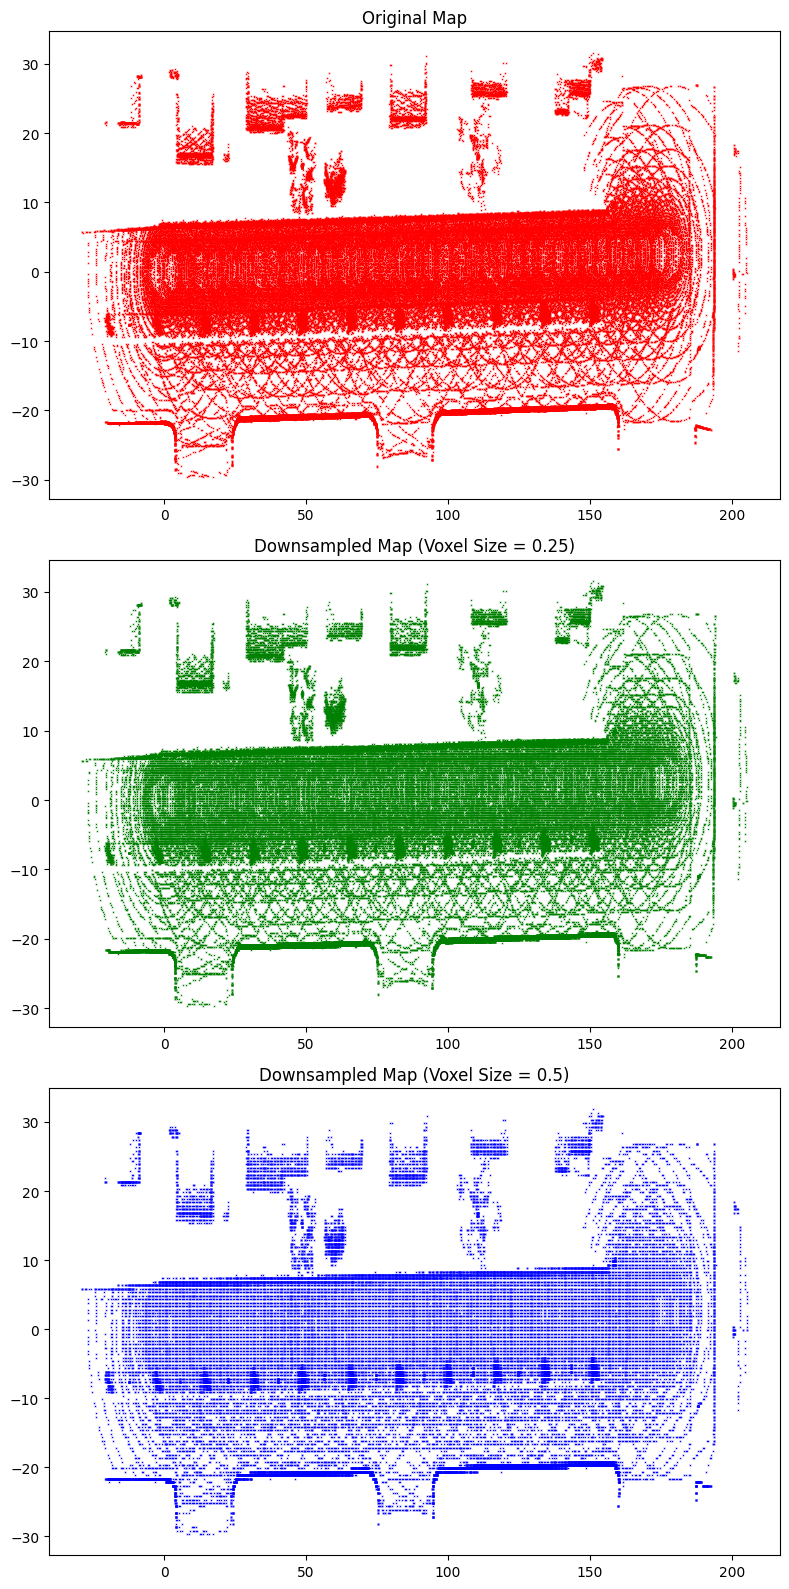

In [28]:
voxel_size = 0.5

# Downsample the point cloud for different purposes
voxel_map_0_5, voxel_config_show = downsample_voxel(map_array, voxel_size=voxel_size)  # Better for plotting purposes
voxel_map_0_25, voxel_config = downsample_voxel(map_array, voxel_size=voxel_size / 2)  # Good for ICP

# Print sizes of the original and downsampled point clouds
print("Point Cloud Sizes:")
print(f"Original shape = {map_array.shape}")
print(f"Voxel size = {voxel_size / 2} -> Downsampled shape = {voxel_map_0_25.shape}")
print(f"Voxel size = {voxel_size} -> Downsampled shape = {voxel_map_0_5.shape}")

# Plot the original and downsampled maps
fig, axs = plt.subplots(3, 1, figsize=(8, 16))

# Plot the original map
axs[0].set_title("Original Map")
plot_pcd(axs[0], map_array, color="red", label="Original", marker='x', s=0.10)

# Plot the map downsampled at voxel_size/2
axs[1].set_title(f"Downsampled Map (Voxel Size = {voxel_size / 2})")
plot_pcd(axs[1], voxel_map_0_25, color="green", label="Downsampled (0.25)", marker='x', s=0.10)

# Plot the map downsampled at voxel_size
axs[2].set_title(f"Downsampled Map (Voxel Size = {voxel_size})")
plot_pcd(axs[2], voxel_map_0_5, color="blue", label="Downsampled (0.5)", marker='x', s=0.10)


plt.tight_layout()
plt.show()


Now Let's examine the effects of downsampling the frame at different voxel sizes.

Point Cloud Sizes:
Original shape = (143949, 3)
Voxel size = 0.25 -> Downsampled shape = (106740, 3)
Voxel size = 0.5 -> Downsampled shape = (44029, 3)


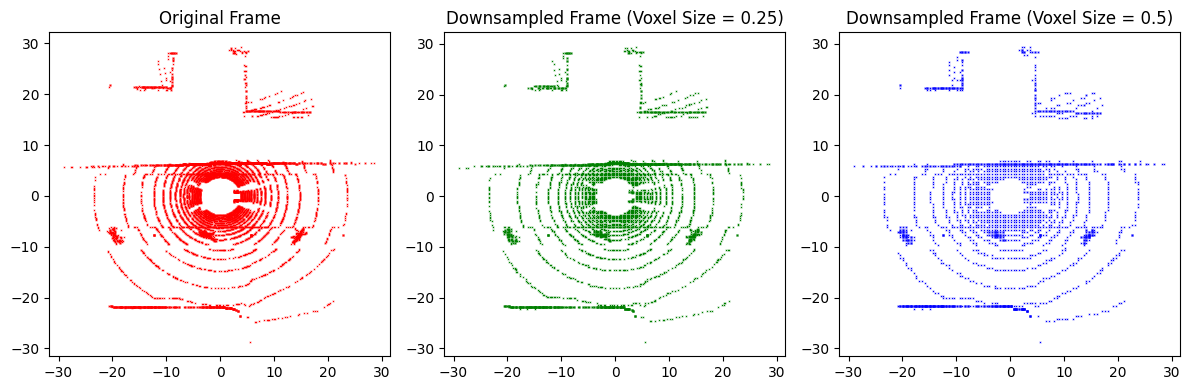

In [29]:
voxel_size = 0.5

# Downsample the point cloud for different purposes
voxel_frame_0_5, voxel_config_show = downsample_voxel(pointcloud_array, voxel_size=voxel_size)  # Better for plotting purposes
voxel_frame_0_25, voxel_config = downsample_voxel(pointcloud_array, voxel_size=voxel_size / 2)  # Good for ICP

# Print sizes of the original and downsampled point clouds
print("Point Cloud Sizes:")
print(f"Original shape = {map_array.shape}")
print(f"Voxel size = {voxel_size / 2} -> Downsampled shape = {voxel_map_0_25.shape}")
print(f"Voxel size = {voxel_size} -> Downsampled shape = {voxel_map_0_5.shape}")

# Plot the original and downsampled maps
fig, axs = plt.subplots(1, 3, figsize=(12, 4))

# Plot the original map
axs[0].set_title("Original Frame")
plot_pcd(axs[0], pointcloud_array, color="red", label="Original", marker='x', s=0.10)

# Plot the map downsampled at voxel_size/2
axs[1].set_title(f"Downsampled Frame (Voxel Size = {voxel_size / 2})")
plot_pcd(axs[1], voxel_frame_0_25, color="green", label="Downsampled (0.25)", marker='x', s=0.10)

# Plot the map downsampled at voxel_size
axs[2].set_title(f"Downsampled Frame (Voxel Size = {voxel_size})")
plot_pcd(axs[2], voxel_frame_0_5, color="blue", label="Downsampled (0.5)", marker='x', s=0.10)


plt.tight_layout()
plt.show()

#### Symplifying further the poincloud to retain only boundaries

In general, the NDT (Normal Distributions Transform) algorithm presented in [Example](../Examples/NDT_localization.ipynb) is designed for 2D localization, as the calculated Jacobians and Hessians assume a **2D** space. The grids used are also 2D, leading to distributions suitable for two-dimensional mapping. However, similar derivations can be applied to achieve the equations required for a **3D** space.

A beneficial approach to improve the efficiency of both NDT and ICP is to simplify point clouds by retaining only their boundaries. This can be achieved using `open3d` to extract boundaries from the point clouds, as shown in the function below:

In [30]:
def boundaries(map_array: np.ndarray, r: float = 2.5, n_iter: int = 2000, zlims: Tuple[float, float] = (-1, 7), device_str: str = "CPU:0") -> np.ndarray:
    """
    Detects boundaries in a voxelized point cloud and trims the results within specified z-limits.

    Args:
    - map_array (np.ndarray): Voxelized point cloud, shape (Nr_points, 3).
    - r (float): Radius to consider points as part of the same object.
    - n_iter (int): Number of iterations for edge detection.
    - zlims (Tuple[float, float]): Minimum and maximum z-values to consider.
    - device_str (str): Device identifier for computation.

    Returns:
    - np.ndarray: Point cloud containing detected boundaries, shape (Nr_points_downsampled, 3).
    """
    # Set up the computation device and data type
    device = o3d.core.Device(device_str)
    dtype = o3d.core.Dtype.Float32

    # Initialize an empty point cloud on the specified device
    tensor_map = o3d.t.geometry.PointCloud(device)

    # Assign data to point cloud
    tensor_map.point['positions'] = o3d.core.Tensor(map_array, dtype, device)

    # Estimate normals for the point cloud
    tensor_map.estimate_normals()

    # Calculate the boundaries of the point cloud using the provided radius and iterations
    boundaries, _ = tensor_map.compute_boundary_points(r, n_iter)

    # Extract the boundary points as a NumPy array
    np_boundaries = boundaries.point['positions'].numpy()

    # Apply z-limits to filter the point cloud
    z_filter = (np_boundaries[:, 2] > zlims[0]) & (np_boundaries[:, 2] < zlims[1])
    np_boundaries = np_boundaries[z_filter]

    return np_boundaries

**Example for Map**

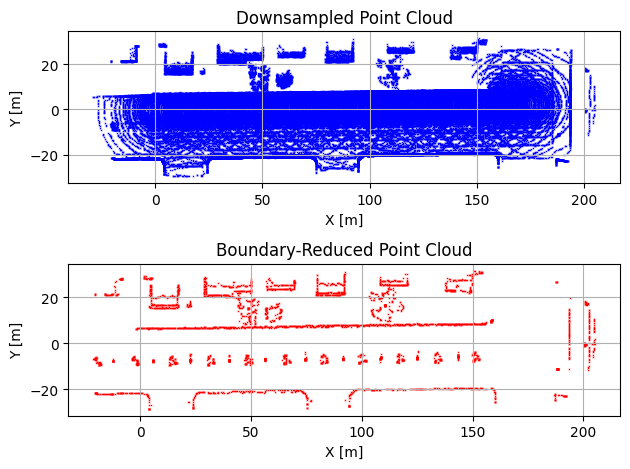

In [31]:
voxel_size = 0.25
r = 2.5
zlims = [0, 7]

# Downsample the point cloud for plotting purposes
voxel_map, voxel_config_show = downsample_voxel(map_array, voxel_size=voxel_size)

# Filter to create a boundary-reduced map
bounded_map = boundaries(voxel_map, r=r, zlims=zlims)

# Plot both the downsampled and boundary-reduced maps
fig, (ax1, ax2) = plt.subplots(2, 1)

# Plot the downsampled map
ax1.set_title("Downsampled Point Cloud")
plot_pcd(ax1, voxel_map, color="blue", label="Downsampled Map", marker='x', s=0.10)
ax1.set_ylabel("Y [m]")
ax1.set_xlabel("X [m]")
ax1.grid()

# Plot the boundary-reduced map
ax2.set_title("Boundary-Reduced Point Cloud")
plot_pcd(ax2, bounded_map, color="red", label="Boundary-Reduced Map", marker='x', s=0.10)
ax2.set_ylabel("Y [m]")
ax2.set_xlabel("X [m]")
ax2.grid()

plt.tight_layout()
plt.show()

**Example for frame**

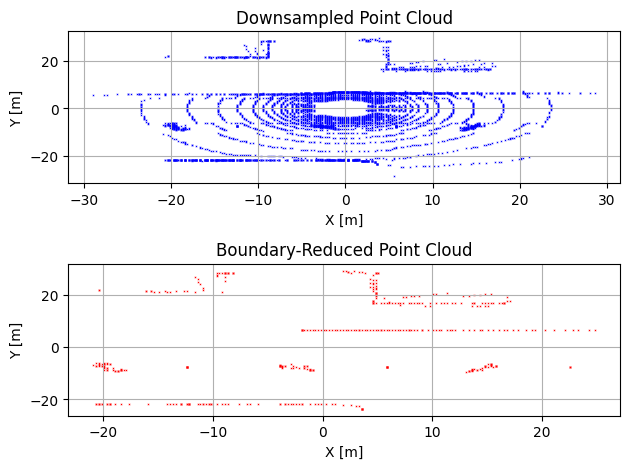

In [32]:
voxel_size = 0.25
r = 2.5
zlims = [0, 7]

# Downsample the point cloud for plotting purposes
voxel_frame, voxel_config_show = downsample_voxel(pointcloud_array, voxel_size=voxel_size)

# Filter to create a boundary-reduced map
bounded_frame = boundaries(voxel_frame, r=r, zlims=zlims)

# Plot both the downsampled and boundary-reduced maps
fig, (ax1, ax2) = plt.subplots(2, 1)

# Plot the downsampled map
ax1.set_title("Downsampled Point Cloud")
plot_pcd(ax1, voxel_frame, color="blue", label="Downsampled Frame", marker='x', s=0.10)
ax1.set_ylabel("Y [m]")
ax1.set_xlabel("X [m]")
ax1.grid()

# Plot the boundary-reduced map
ax2.set_title("Boundary-Reduced Point Cloud")
plot_pcd(ax2, bounded_frame, color="red", label="Boundary-Reduced Frame", marker='x', s=0.10)
ax2.set_ylabel("Y [m]")
ax2.set_xlabel("X [m]")
ax2.grid()

plt.tight_layout()
plt.show()

### Further simplifications

If you're encountering challenges with the NDT algorithm, here are some practical suggestions to consider, especially if you aim to use the 2D formulation:

1. **Convert the Map and frame to 2D:** Since the vehicle primarily moves on a flat road, you can simplify the point cloud data by working in 2D. Ground truth data indicates that variations in the z-coordinate, roll, and pitch are minimal. Thus, you can:

    - **Filter Ground Points:** Remove points representing the road surface since they contribute little unique mapping information.
    - **Limit Maximum Height:** Set a reasonable height limit to focus on features relevant to the vehicle's navigation.
    - **Use X and Y Coordinates Only:** For both the map and frame, retain only the X and Y coordinates, setting the z-coordinate to zero.

By reducing the data to a 2D map, the NDT algorithm becomes more computationally efficient and easier to handle. Additionally, this simplification helps to identify relevant landmarks for accurate localization, making the process more robust and reliable.

In [44]:
def get_gt_pose(frame_num):
    gt = gts.iloc[frame_num]
    # Direkt auf die Werte zugreifen statt über Namen
    pos = np.array([gt[1], gt[2], gt[3]])  # x, y, z
    orientation = np.array([gt[4], gt[5], gt[6]])  # roll, pitch, yaw
    return pos, orientation

In [45]:
def localize_with_icp(frame_points, map_points, initial_transform=None):
    """Lokalisiert das Fahrzeug mittels ICP-Algorithmus."""
    # Frame und Karte in Open3D-Punktwolken umwandeln
    frame_pcd = o3d.geometry.PointCloud()
    frame_pcd.points = o3d.utility.Vector3dVector(frame_points)
    
    map_pcd = o3d.geometry.PointCloud()
    map_pcd.points = o3d.utility.Vector3dVector(map_points)
    
    # ICP-Registrierung durchführen
    if initial_transform is None:
        initial_transform = np.eye(4)  # Identitätsmatrix als Startwert
        
    result = o3d.pipelines.registration.registration_icp(
        frame_pcd, map_pcd, 0.5,  # max_correspondence_distance
        initial_transform,
        o3d.pipelines.registration.TransformationEstimationPointToPoint(),
        o3d.pipelines.registration.ICPConvergenceCriteria(max_iteration=100)
    )
    
    return result.transformation


In [46]:
def process_all_frames():
    """Verarbeitet alle Frames und berechnet die Lokalisierungsfehler."""
    # Karte laden und downsampling
    map_array = pcd_from_path("./dataset/map.pcd")
    voxel_map, _ = downsample_voxel(map_array, voxel_size=0.25)
    
    # Ergebnisse speichern
    results = []
    
    # Transformation für den vorherigen Frame (für kontinuierliche Lokalisierung)
    prev_transform = np.eye(4)
    
    for frame_num in range(1014):  # 0 bis 1013
        print(f"Verarbeite Frame {frame_num}")
        
        # Frame laden und downsampling
        frame_path = f"./dataset/frames/frame_{frame_num}.pcd"
        frame_array = pcd_from_path(frame_path)
        voxel_frame, _ = downsample_voxel(frame_array, voxel_size=0.25)
        
        # Lokalisierung durchführen
        transform = localize_with_icp(voxel_frame, voxel_map, prev_transform)
        prev_transform = transform
        
        # Geschätzte Position und Orientierung extrahieren
        estimated_pos = transform[:3, 3]
        estimated_orientation = Rotation.from_matrix(transform[:3, :3]).as_euler("xyz")
        
        # Ground-Truth-Werte abrufen
        gt_pos, gt_orientation = get_gt_pose(frame_num)
        
        # Fehler berechnen
        position_error = np.linalg.norm(estimated_pos[:2] - gt_pos[:2])  # Lateraler Fehler
        yaw_error = gt_orientation[2] - estimated_orientation[2]  # Yaw-Winkelfehler
        
        results.append({
            'frame': frame_num,
            'estimated_pos': estimated_pos,
            'estimated_orientation': estimated_orientation,
            'gt_pos': gt_pos,
            'gt_orientation': gt_orientation,
            'position_error': position_error,
            'yaw_error': yaw_error
        })
    
    return results


In [47]:
def visualize_results(results):
    """Visualisiert die Lokalisierungsergebnisse."""
    frames = [r['frame'] for r in results]
    position_errors = [r['position_error'] for r in results]
    yaw_errors = [r['yaw_error'] for r in results]
    
    # Positionsfehler plotten
    plt.figure(figsize=(12, 6))
    plt.subplot(2, 1, 1)
    plt.plot(frames, position_errors)
    plt.title('Lateraler Positionsfehler')
    plt.xlabel('Frame')
    plt.ylabel('Fehler (m)')
    plt.grid(True)
    
    # Yaw-Fehler plotten
    plt.subplot(2, 1, 2)
    plt.plot(frames, yaw_errors)
    plt.title('Yaw-Winkelfehler')
    plt.xlabel('Frame')
    plt.ylabel('Fehler (rad)')
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()
    
    # Trajektorie plotten
    plt.figure(figsize=(10, 8))
    gt_x = [r['gt_pos'][0] for r in results]
    gt_y = [r['gt_pos'][1] for r in results]
    est_x = [r['estimated_pos'][0] for r in results]
    est_y = [r['estimated_pos'][1] for r in results]
    
    plt.plot(gt_x, gt_y, 'b-', label='Ground Truth')
    plt.plot(est_x, est_y, 'r-', label='Geschätzt')
    plt.title('Fahrzeugtrajektorie')
    plt.xlabel('X (m)')
    plt.ylabel('Y (m)')
    plt.legend()
    plt.grid(True)
    plt.axis('equal')
    plt.show()


Verarbeite Frame 0
Verarbeite Frame 1
Verarbeite Frame 2


C:\Users\danie\AppData\Local\Temp\ipykernel_6796\3670196545.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  pos = np.array([gt[1], gt[2], gt[3]])  # x, y, z
C:\Users\danie\AppData\Local\Temp\ipykernel_6796\3670196545.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  orientation = np.array([gt[4], gt[5], gt[6]])  # roll, pitch, yaw


Verarbeite Frame 3
Verarbeite Frame 4
Verarbeite Frame 5
Verarbeite Frame 6
Verarbeite Frame 7
Verarbeite Frame 8
Verarbeite Frame 9
Verarbeite Frame 10
Verarbeite Frame 11
Verarbeite Frame 12
Verarbeite Frame 13
Verarbeite Frame 14
Verarbeite Frame 15
Verarbeite Frame 16
Verarbeite Frame 17
Verarbeite Frame 18
Verarbeite Frame 19
Verarbeite Frame 20
Verarbeite Frame 21
Verarbeite Frame 22
Verarbeite Frame 23
Verarbeite Frame 24
Verarbeite Frame 25
Verarbeite Frame 26
Verarbeite Frame 27
Verarbeite Frame 28
Verarbeite Frame 29
Verarbeite Frame 30
Verarbeite Frame 31
Verarbeite Frame 32
Verarbeite Frame 33
Verarbeite Frame 34
Verarbeite Frame 35
Verarbeite Frame 36
Verarbeite Frame 37
Verarbeite Frame 38
Verarbeite Frame 39
Verarbeite Frame 40
Verarbeite Frame 41
Verarbeite Frame 42
Verarbeite Frame 43
Verarbeite Frame 44
Verarbeite Frame 45
Verarbeite Frame 46
Verarbeite Frame 47
Verarbeite Frame 48
Verarbeite Frame 49
Verarbeite Frame 50
Verarbeite Frame 51
Verarbeite Frame 52
Verarbe

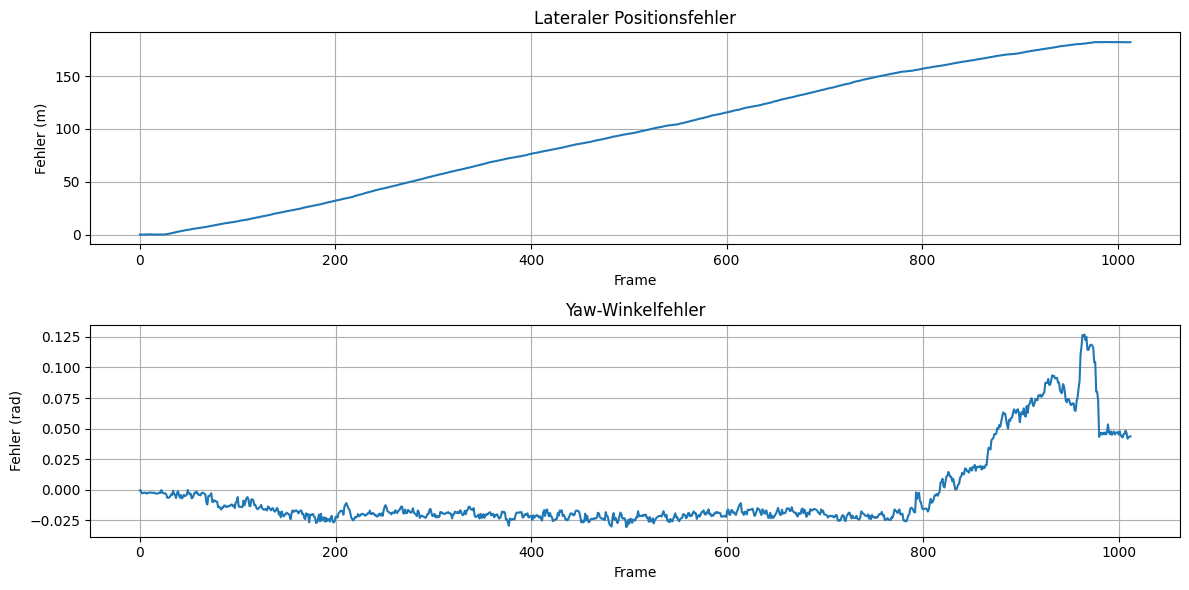

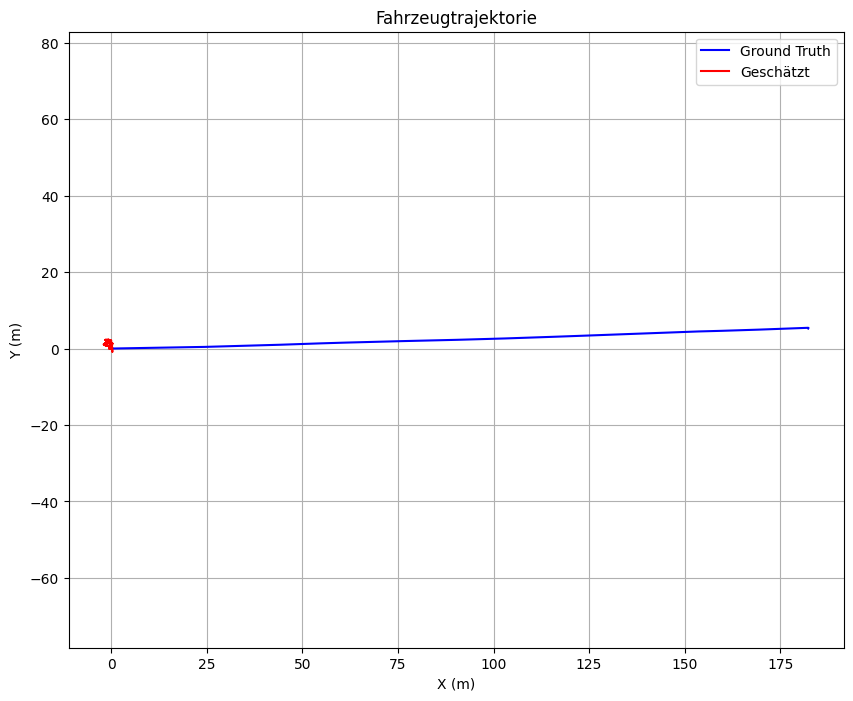

In [48]:
res = process_all_frames()
visualize_results(res)

# Next try

In [49]:
def improved_localize_with_icp(frame_points, map_points, initial_transform=None, prev_velocity=None):
    """
    Verbesserte ICP-Lokalisierung mit mehreren Verfeinerungsschritten
    """
    # Punktwolken in Open3D-Format konvertieren
    frame_pcd = o3d.geometry.PointCloud()
    frame_pcd.points = o3d.utility.Vector3dVector(frame_points)
    
    map_pcd = o3d.geometry.PointCloud()
    map_pcd.points = o3d.utility.Vector3dVector(map_points)
    
    # Normalen berechnen für Point-to-Plane ICP
    frame_pcd.estimate_normals(search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=0.5, max_nn=30))
    map_pcd.estimate_normals(search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=0.5, max_nn=30))
    
    # Wenn keine initiale Transformation gegeben ist, Schwerpunkt-Ausrichtung verwenden
    if initial_transform is None:
        initial_transform = np.eye(4)
        
    # Mehrstufiger ICP-Prozess mit abnehmenden Distanzschwellen
    distances = [2.0, 1.0, 0.5, 0.25]
    current_transform = initial_transform
    
    for distance in distances:
        result = o3d.pipelines.registration.registration_icp(
            frame_pcd, map_pcd, 
            distance,  # Maximale Korrespondenzdistanz
            current_transform,
            o3d.pipelines.registration.TransformationEstimationPointToPlane(),
            o3d.pipelines.registration.ICPConvergenceCriteria(
                max_iteration=50,
                relative_fitness=1e-6,
                relative_rmse=1e-6
            )
        )
        current_transform = result.transformation
    
    return current_transform


In [50]:
def preprocess_point_cloud(point_cloud, voxel_size, remove_ground=True, height_limits=None):
    """
    Verbesserte Punktwolkenvorverarbeitung mit Bodenentfernung und Höhenbegrenzung
    """
    # Punktwolke in Open3D-Format konvertieren
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(point_cloud)
    
    # Downsampling mit Voxel-Grid
    pcd_down = pcd.voxel_down_sample(voxel_size=voxel_size)
    
    # Boden entfernen (optional)
    if remove_ground:
        # RANSAC-Ebenenanpassung für Bodenerkennung
        plane_model, inliers = pcd_down.segment_plane(distance_threshold=0.2, 
                                                     ransac_n=3, 
                                                     num_iterations=100)
        # Boden-Inliers entfernen
        outlier_cloud = pcd_down.select_by_index(inliers, invert=True)
        pcd_down = outlier_cloud
    
    # Höhenbegrenzung anwenden (optional)
    if height_limits is not None:
        min_height, max_height = height_limits
        points = np.asarray(pcd_down.points)
        mask = (points[:, 2] >= min_height) & (points[:, 2] <= max_height)
        filtered_points = points[mask]
        
        pcd_filtered = o3d.geometry.PointCloud()
        pcd_filtered.points = o3d.utility.Vector3dVector(filtered_points)
        pcd_down = pcd_filtered
    
    # Ausreißer entfernen
    pcd_down, _ = pcd_down.remove_statistical_outlier(nb_neighbors=20, std_ratio=2.0)
    
    return np.asarray(pcd_down.points)


In [92]:
def process_all_frames_improved():
    """
    Verbesserte Verarbeitung aller Frames mit Bewegungsmodell und Fehlerbehandlung
    """
    # Karte laden und vorverarbeiten
    map_array = pcd_from_path("./dataset/map.pcd")
    map_processed = preprocess_point_cloud(
        map_array, 
        voxel_size=0.25, 
        remove_ground=True, 
        height_limits=(0.3, 5.0)
    )
    
    # Ergebnisse speichern
    results = []
    
    # Initialisierung
    prev_transform = np.eye(4)
    prev_velocity = np.zeros(3)  # [vx, vy, omega]
    alpha = 0.7  # Gewichtung für Bewegungsmodell (0-1)
    
    for frame_num in range(1014):
        try:
            print(f"Verarbeite Frame {frame_num}")
            
            # Frame laden und vorverarbeiten
            frame_path = f"./dataset/frames/frame_{frame_num}.pcd"
            frame_array = pcd_from_path(frame_path)
            frame_processed = preprocess_point_cloud(
                frame_array, 
                voxel_size=0.15,  # Feinere Voxelgröße für Frames
                remove_ground=True, 
                height_limits=(0.3, 5.0)
            )
            
            # Bewegungsmodell für Prädiktion
            if frame_num > 0:
                # Einfaches Bewegungsmodell basierend auf vorherigem Frame
                dt = 1.0  # Annahme: konstante Zeitschritte
                motion_prediction = np.eye(4)
                motion_prediction[:3, 3] = prev_transform[:3, 3] + prev_velocity * dt
                
                # Gewichtete Kombination aus Bewegungsmodell und vorheriger Position
                initial_guess = np.eye(4)
                initial_guess[:3, :3] = prev_transform[:3, :3]
                initial_guess[:3, 3] = alpha * motion_prediction[:3, 3] + (1-alpha) * prev_transform[:3, 3]
            else:
                initial_guess = np.eye(4)
            
            # Lokalisierung durchführen
            transform = improved_localize_with_icp(
                frame_processed, 
                map_processed, 
                initial_transform=initial_guess,
                prev_velocity=prev_velocity
            )
            
            # Geschwindigkeit aktualisieren
            if frame_num > 0:
                current_pos = transform[:3, 3]
                prev_pos = prev_transform[:3, 3]
                prev_velocity = (current_pos - prev_pos)
            
            prev_transform = transform
            
            # Geschätzte Position und Orientierung extrahieren
            estimated_pos = transform[:3, 3]
            r = Rotation.from_matrix(transform[:3, :3])
            estimated_orientation = r.as_euler("xyz")
            
            # Ground-Truth-Werte abrufen
            gt_pos, gt_orientation = get_gt_pose(frame_num)
            
            # Fehler berechnen
            position_error = np.linalg.norm(estimated_pos[:2] - gt_pos[:2])
            yaw_error = np.abs(gt_orientation[2] - estimated_orientation[2])
            yaw_error = min(yaw_error, 2*np.pi - yaw_error)  # Berücksichtigung der Periodizität
            
            results.append({
                'frame': frame_num,
                'estimated_pos': estimated_pos,
                'estimated_orientation': estimated_orientation,
                'gt_pos': gt_pos,
                'gt_orientation': gt_orientation,
                'position_error': position_error,
                'yaw_error': yaw_error,
                'transform': transform
            })
            
        except Exception as e:
            print(f"process_all_frames_improved Fehler bei Frame {frame_num}: {e}")
            # Wenn ein Frame fehlschlägt, vorherigen Zustand beibehalten
            if frame_num > 0 and results:
                last_result = results[-1].copy()
                last_result['frame'] = frame_num
                results.append(last_result)
    
    return results


In [59]:
def visualize_with_point_clouds(results, sample_frames=[0, 250, 500, 750, 1000]):
    """
    Visualisiert die Lokalisierungsergebnisse mit überlagerten Punktwolken
    """
    # Karte laden
    try:
        map_array = pcd_from_path("./dataset/map.pcd")
        map_pcd = o3d.geometry.PointCloud()
        map_pcd.points = o3d.utility.Vector3dVector(map_array)
        map_pcd.paint_uniform_color([0.5, 0.5, 0.5])  # Grau für die Karte
    except Exception as e:
        print(f"Fehler beim Laden der Karte: {e}")
        return
    
    for frame_num in sample_frames:
        if frame_num >= len(results):
            print(f"Frame {frame_num} ist außerhalb des Bereichs.")
            continue
            
        try:
            result = results[frame_num]
            transform = result['transform']
            
            # Frame laden
            frame_path = f"./dataset/frames/frame_{frame_num}.pcd"
            frame_array = pcd_from_path(frame_path)
            frame_pcd = o3d.geometry.PointCloud()
            frame_pcd.points = o3d.utility.Vector3dVector(frame_array)
            frame_pcd.paint_uniform_color([1, 0, 0])  # Rot für den Frame
            
            # Frame mit geschätzter Transformation transformieren
            frame_pcd_transformed = frame_pcd.transform(transform)
            
            # Visualisierung
            print(f"Visualisierung für Frame {frame_num}")
            print(f"Geschätzte Position: {result['estimated_pos']}")
            print(f"Ground Truth Position: {result['gt_pos']}")
            print(f"Positionsfehler: {result['position_error']:.3f} m")
            print(f"Orientierungsfehler: {result['yaw_error'] if 'yaw_error' in result else 'N/A'} rad")
            
            # Koordinatensysteme erstellen
            frame_size = 2.0
            gt_frame = o3d.geometry.TriangleMesh.create_coordinate_frame(size=frame_size)
            est_frame = o3d.geometry.TriangleMesh.create_coordinate_frame(size=frame_size)
            
            # Ground Truth Transformation
            gt_transform = np.eye(4)
            gt_transform[:3, 3] = result['gt_pos']
            if 'gt_orientation' in result and all(not np.isnan(x) for x in result['gt_orientation']):
                gt_r = Rotation.from_euler('xyz', result['gt_orientation']).as_matrix()
                gt_transform[:3, :3] = gt_r
            gt_frame.transform(gt_transform)
            
            # Visualisierung
            o3d.visualization.draw_geometries([
                map_pcd,  # Karte
                frame_pcd_transformed,  # Transformierter Frame
                gt_frame,  # Ground Truth Position
                est_frame.transform(transform)  # Geschätzte Position
            ], window_name=f"Frame {frame_num}")
            
        except Exception as e:
            print(f"Fehler bei der Visualisierung von Frame {frame_num}: {e}")


In [60]:
def visualize_point_clouds_matplotlib(results, sample_frames=[0, 250, 500, 750, 1000]):
    """
    Visualisiert die Lokalisierungsergebnisse mit überlagerten Punktwolken in Matplotlib
    """
    # Karte laden
    try:
        map_array = pcd_from_path("./dataset/map.pcd")
    except Exception as e:
        print(f"Fehler beim Laden der Karte: {e}")
        return
    
    for frame_num in sample_frames:
        if frame_num >= len(results):
            print(f"Frame {frame_num} ist außerhalb des Bereichs.")
            continue
            
        try:
            result = results[frame_num]
            transform = result['transform']
            
            # Frame laden
            frame_path = f"./dataset/frames/frame_{frame_num}.pcd"
            frame_array = pcd_from_path(frame_path)
            
            # Frame mit geschätzter Transformation transformieren
            # Homogene Koordinaten erstellen
            homogeneous_points = np.hstack((frame_array, np.ones((frame_array.shape[0], 1))))
            # Transformation anwenden
            transformed_points = (transform @ homogeneous_points.T).T[:, :3]
            
            # Visualisierung mit Matplotlib
            fig = plt.figure(figsize=(12, 10))
            ax = fig.add_subplot(111, projection='3d')
            
            # Karte plotten (zufällige Stichprobe für bessere Performance)
            sample_size = min(10000, map_array.shape[0])
            sample_indices = np.random.choice(map_array.shape[0], sample_size, replace=False)
            ax.scatter(map_array[sample_indices, 0], 
                      map_array[sample_indices, 1], 
                      map_array[sample_indices, 2], 
                      c='gray', marker='.', s=1, alpha=0.5, label='Karte')
            
            # Transformierten Frame plotten
            sample_size = min(5000, transformed_points.shape[0])
            sample_indices = np.random.choice(transformed_points.shape[0], sample_size, replace=False)
            ax.scatter(transformed_points[sample_indices, 0], 
                      transformed_points[sample_indices, 1], 
                      transformed_points[sample_indices, 2], 
                      c='red', marker='.', s=2, label='Frame (geschätzt)')
            
            # Ground Truth Position plotten
            gt_pos = result['gt_pos']
            ax.scatter(gt_pos[0], gt_pos[1], gt_pos[2], 
                      c='green', marker='o', s=100, label='Ground Truth')
            
            # Geschätzte Position plotten
            est_pos = result['estimated_pos']
            ax.scatter(est_pos[0], est_pos[1], est_pos[2], 
                      c='blue', marker='o', s=100, label='Geschätzt')
            
            # Achsenbeschriftungen und Titel
            ax.set_xlabel('X (m)')
            ax.set_ylabel('Y (m)')
            ax.set_zlabel('Z (m)')
            ax.set_title(f'Frame {frame_num} - Fehler: {result["position_error"]:.3f} m')
            
            # Legende und Ansicht anpassen
            ax.legend()
            ax.view_init(elev=30, azim=45)
            
            # Statistik anzeigen
            info_text = (f"Geschätzte Position: {est_pos}\n"
                        f"Ground Truth Position: {gt_pos}\n"
                        f"Positionsfehler: {result['position_error']:.3f} m")
            
            plt.figtext(0.02, 0.02, info_text, fontsize=10)
            
            plt.tight_layout()
            plt.show()
            
        except Exception as e:
            print(f"Fehler bei der Visualisierung von Frame {frame_num}: {e}")


In [58]:
def visualize_trajectory_comparison(results):
    """
    Visualisiert die geschätzte und Ground-Truth-Trajektorie mit Fehlervisualisierung
    """
    fig, ax = plt.subplots(figsize=(12, 10))
    
    # Daten extrahieren
    frames = [r['frame'] for r in results]
    gt_x = [r['gt_pos'][0] for r in results]
    gt_y = [r['gt_pos'][1] for r in results]
    est_x = [r['estimated_pos'][0] for r in results]
    est_y = [r['estimated_pos'][1] for r in results]
    errors = [r['position_error'] for r in results]
    
    # Farbkarte für Fehler erstellen
    cmap = plt.cm.jet
    norm = plt.Normalize(0, max(errors))
    
    # Ground Truth Trajektorie plotten
    ax.plot(gt_x, gt_y, 'k-', linewidth=2, label='Ground Truth')
    
    # Geschätzte Trajektorie mit Fehlerfarben plotten
    points = np.array([est_x, est_y]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    lc = matplotlib.collections.LineCollection(segments, cmap=cmap, norm=norm)
    lc.set_array(np.array(errors))
    lc.set_linewidth(2)
    line = ax.add_collection(lc)
    
    # Verbindungslinien zwischen geschätzter und Ground-Truth-Position
    for i in range(0, len(frames), 50):  # Alle 50 Frames
        ax.plot([gt_x[i], est_x[i]], [gt_y[i], est_y[i]], 'r--', alpha=0.3)
        
    # Startpunkte markieren
    ax.plot(gt_x[0], gt_y[0], 'go', markersize=10, label='Start')
    ax.plot(est_x[0], est_y[0], 'bo', markersize=10)
    
    # Endpunkte markieren
    ax.plot(gt_x[-1], gt_y[-1], 'ro', markersize=10, label='Ende')
    ax.plot(est_x[-1], est_y[-1], 'mo', markersize=10)
    
    # Farbbalken für Fehler
    cbar = fig.colorbar(line, ax=ax)
    cbar.set_label('Positionsfehler (m)')
    
    # Achsen und Titel
    ax.set_title('Vergleich von geschätzter und Ground-Truth-Trajektorie')
    ax.set_xlabel('X (m)')
    ax.set_ylabel('Y (m)')
    ax.legend()
    ax.grid(True)
    ax.axis('equal')
    
    # Fehlerstatistik anzeigen
    avg_error = np.mean(errors)
    max_error = np.max(errors)
    min_error = np.min(errors)
    std_error = np.std(errors)
    
    stats_text = (f'Fehlerstatistik:\n'
                 f'Min: {min_error:.2f} m\n'
                 f'Max: {max_error:.2f} m\n'
                 f'Mittelwert: {avg_error:.2f} m\n'
                 f'Std.abw.: {std_error:.2f} m')
    
    # Text in einer Box anzeigen
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
    ax.text(0.05, 0.05, stats_text, transform=ax.transAxes, fontsize=10,
            verticalalignment='bottom', bbox=props)
    
    plt.tight_layout()
    plt.show()
    
    # Zusätzlich einen Fehler-über-Zeit-Plot erstellen
    plt.figure(figsize=(12, 6))
    plt.plot(frames, errors, 'b-')
    plt.axhline(y=avg_error, color='r', linestyle='--', label=f'Mittelwert: {avg_error:.2f} m')
    plt.fill_between(frames, 
                     [avg_error - std_error] * len(frames), 
                     [avg_error + std_error] * len(frames), 
                     color='r', alpha=0.2, 
                     label=f'Std.abw.: {std_error:.2f} m')
    plt.title('Positionsfehler über Zeit')
    plt.xlabel('Frame')
    plt.ylabel('Fehler (m)')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


In [54]:
def localize_with_ndt(frame_points, map_points, initial_transform=None):
    """
    Lokalisierung mit NDT (Normal Distributions Transform)
    """
    # Punktwolken in Open3D-Format konvertieren
    frame_pcd = o3d.geometry.PointCloud()
    frame_pcd.points = o3d.utility.Vector3dVector(frame_points)
    
    map_pcd = o3d.geometry.PointCloud()
    map_pcd.points = o3d.utility.Vector3dVector(map_points)
    
    # Initiale Transformation
    if initial_transform is None:
        initial_transform = np.eye(4)
    
    # NDT-Parameter
    ndt_param = o3d.pipelines.registration.NDTRegistrationResult()
    ndt_param.transformation = initial_transform
    
    # NDT-Registrierung
    result = o3d.pipelines.registration.registration_ndt(
        frame_pcd,
        map_pcd,
        2.0,  # Auflösung der Voxel-Grid
        ndt_param,
        o3d.pipelines.registration.TransformationEstimationPointToPoint(),
        o3d.pipelines.registration.ICPConvergenceCriteria(max_iteration=50)
    )
    
    return result.transformation


In [55]:
class SimpleKalmanFilter:
    def __init__(self, process_noise=0.01, measurement_noise=0.1):
        # Zustandsvektor: [x, y, z, roll, pitch, yaw, vx, vy, vz, vroll, vpitch, vyaw]
        self.state = np.zeros(12)
        self.P = np.eye(12)  # Kovarianzmatrix
        self.Q = np.eye(12) * process_noise  # Prozessrauschen
        self.R = np.eye(6) * measurement_noise  # Messrauschen
        
    def predict(self, dt=1.0):
        # Einfaches Bewegungsmodell: Position += Geschwindigkeit * dt
        F = np.eye(12)
        F[0, 6] = dt  # x += vx * dt
        F[1, 7] = dt  # y += vy * dt
        F[2, 8] = dt  # z += vz * dt
        F[3, 9] = dt  # roll += vroll * dt
        F[4, 10] = dt  # pitch += vpitch * dt
        F[5, 11] = dt  # yaw += vyaw * dt
        
        # Zustand vorhersagen
        self.state = F @ self.state
        
        # Kovarianz aktualisieren
        self.P = F @ self.P @ F.T + self.Q
        
        return self.state[:6]  # Nur Position und Orientierung zurückgeben
    
    def update(self, measurement):
        # Measurement: [x, y, z, roll, pitch, yaw]
        H = np.zeros((6, 12))
        H[:6, :6] = np.eye(6)  # Messmatrix
        
        # Kalman-Gain berechnen
        S = H @ self.P @ H.T + self.R
        K = self.P @ H.T @ np.linalg.inv(S)
        
        # Zustand aktualisieren
        y = measurement - H @ self.state
        self.state = self.state + K @ y
        
        # Kovarianz aktualisieren
        self.P = (np.eye(12) - K @ H) @ self.P
        
        return self.state[:6]  # Nur Position und Orientierung zurückgeben


In [56]:
def process_frames_in_batches(batch_size=50):
    """
    Verarbeitet Frames in Batches für bessere Speichereffizienz
    """
    # Karte laden und vorverarbeiten (einmalig)
    map_array = pcd_from_path("./dataset/map.pcd")
    map_processed = preprocess_point_cloud(map_array, voxel_size=0.25, remove_ground=True)
    
    # Kalman-Filter initialisieren
    kf = SimpleKalmanFilter()
    
    # Initialisierung
    prev_transform = np.eye(4)
    all_results = []
    
    # Verarbeitung in Batches
    total_frames = 1014
    for batch_start in range(0, total_frames, batch_size):
        batch_end = min(batch_start + batch_size, total_frames)
        batch_results = []
        
        print(f"Verarbeite Batch {batch_start} bis {batch_end-1}")
        
        for frame_num in range(batch_start, batch_end):
            # Frame laden und verarbeiten
            frame_path = f"./dataset/frames/frame_{frame_num}.pcd"
            frame_array = pcd_from_path(frame_path)
            frame_processed = preprocess_point_cloud(frame_array, voxel_size=0.15)
            
            # Kalman-Filter-Vorhersage
            kf.predict()
            
            # Lokalisierung durchführen
            transform = improved_localize_with_icp(frame_processed, map_processed, prev_transform)
            prev_transform = transform
            
            # Geschätzte Position und Orientierung extrahieren
            estimated_pos = transform[:3, 3]
            r = Rotation.from_matrix(transform[:3, :3])
            estimated_orientation = r.as_euler("xyz")
            
            # Kalman-Filter-Update
            measurement = np.concatenate([estimated_pos, estimated_orientation])
            filtered_state = kf.update(measurement)
            
            # Ground-Truth-Werte abrufen
            gt_pos, gt_orientation = get_gt_pose(frame_num)
            
            # Ergebnisse speichern
            batch_results.append({
                'frame': frame_num,
                'estimated_pos': estimated_pos,
                'estimated_orientation': estimated_orientation,
                'filtered_pos': filtered_state[:3],
                'filtered_orientation': filtered_state[3:6],
                'gt_pos': gt_pos,
                'gt_orientation': gt_orientation,
                'transform': transform
            })
        
        # Batch-Ergebnisse zum Gesamtergebnis hinzufügen
        all_results.extend(batch_results)
        
        # Zwischenergebnisse speichern (optional)
        np.save(f"results_batch_{batch_start}_{batch_end-1}.npy", batch_results)
    
    return all_results


In [61]:
def analyze_errors(results):
    """
    Führt eine detaillierte Analyse der Lokalisierungsfehler durch
    """
    frames = [r['frame'] for r in results]
    position_errors = [r['position_error'] for r in results]
    
    # Grundlegende Statistiken
    avg_error = np.mean(position_errors)
    median_error = np.median(position_errors)
    max_error = np.max(position_errors)
    min_error = np.min(position_errors)
    std_error = np.std(position_errors)
    
    print("=== Fehlerstatistik ===")
    print(f"Durchschnittlicher Fehler: {avg_error:.3f} m")
    print(f"Median-Fehler: {median_error:.3f} m")
    print(f"Minimaler Fehler: {min_error:.3f} m")
    print(f"Maximaler Fehler: {max_error:.3f} m")
    print(f"Standardabweichung: {std_error:.3f} m")
    
    # Frames mit den größten Fehlern identifizieren
    worst_indices = np.argsort(position_errors)[-10:][::-1]
    print("\n=== Die 10 schlechtesten Frames ===")
    for idx in worst_indices:
        print(f"Frame {frames[idx]}: Fehler = {position_errors[idx]:.3f} m")
    
    # Histogramm der Fehler
    plt.figure(figsize=(10, 6))
    plt.hist(position_errors, bins=30, alpha=0.7, color='blue')
    plt.axvline(avg_error, color='red', linestyle='--', label=f'Mittelwert: {avg_error:.3f} m')
    plt.axvline(median_error, color='green', linestyle='--', label=f'Median: {median_error:.3f} m')
    plt.title('Verteilung der Positionsfehler')
    plt.xlabel('Fehler (m)')
    plt.ylabel('Anzahl der Frames')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Fehler über Zeit (mit gleitendem Durchschnitt)
    plt.figure(figsize=(12, 6))
    plt.plot(frames, position_errors, 'b-', alpha=0.5, label='Fehler')
    
    # Gleitender Durchschnitt
    window_size = 20
    if len(frames) > window_size:
        moving_avg = np.convolve(position_errors, np.ones(window_size)/window_size, mode='valid')
        plt.plot(frames[window_size-1:], moving_avg, 'r-', linewidth=2, 
                 label=f'Gleitender Durchschnitt (Fenster: {window_size})')
    
    plt.title('Positionsfehler über Zeit')
    plt.xlabel('Frame')
    plt.ylabel('Fehler (m)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
    return {
        'avg_error': avg_error,
        'median_error': median_error,
        'max_error': max_error,
        'min_error': min_error,
        'std_error': std_error,
        'worst_frames': [frames[idx] for idx in worst_indices]
    }


Verarbeite Frame 0
Verarbeite Frame 1
Verarbeite Frame 2


C:\Users\danie\AppData\Local\Temp\ipykernel_6796\3670196545.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  pos = np.array([gt[1], gt[2], gt[3]])  # x, y, z
C:\Users\danie\AppData\Local\Temp\ipykernel_6796\3670196545.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  orientation = np.array([gt[4], gt[5], gt[6]])  # roll, pitch, yaw


Verarbeite Frame 3
Verarbeite Frame 4
Verarbeite Frame 5
Verarbeite Frame 6
Verarbeite Frame 7
Verarbeite Frame 8
Verarbeite Frame 9
Verarbeite Frame 10
Verarbeite Frame 11
Verarbeite Frame 12
Verarbeite Frame 13
Verarbeite Frame 14
Verarbeite Frame 15
Verarbeite Frame 16
Verarbeite Frame 17
Verarbeite Frame 18
Verarbeite Frame 19
Verarbeite Frame 20
Verarbeite Frame 21
Verarbeite Frame 22
Verarbeite Frame 23
Verarbeite Frame 24
Verarbeite Frame 25
Verarbeite Frame 26
Verarbeite Frame 27
Verarbeite Frame 28
Verarbeite Frame 29
Verarbeite Frame 30
Verarbeite Frame 31
Verarbeite Frame 32
Verarbeite Frame 33
Verarbeite Frame 34
Verarbeite Frame 35
Verarbeite Frame 36
Verarbeite Frame 37
Verarbeite Frame 38
Verarbeite Frame 39
Verarbeite Frame 40
Verarbeite Frame 41
Verarbeite Frame 42
Verarbeite Frame 43
Verarbeite Frame 44
Verarbeite Frame 45
Verarbeite Frame 46
Verarbeite Frame 47
Verarbeite Frame 48
Verarbeite Frame 49
Verarbeite Frame 50
Verarbeite Frame 51
Verarbeite Frame 52
Verarbe

ValueError: Unable to determine Axes to steal space for Colorbar. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.

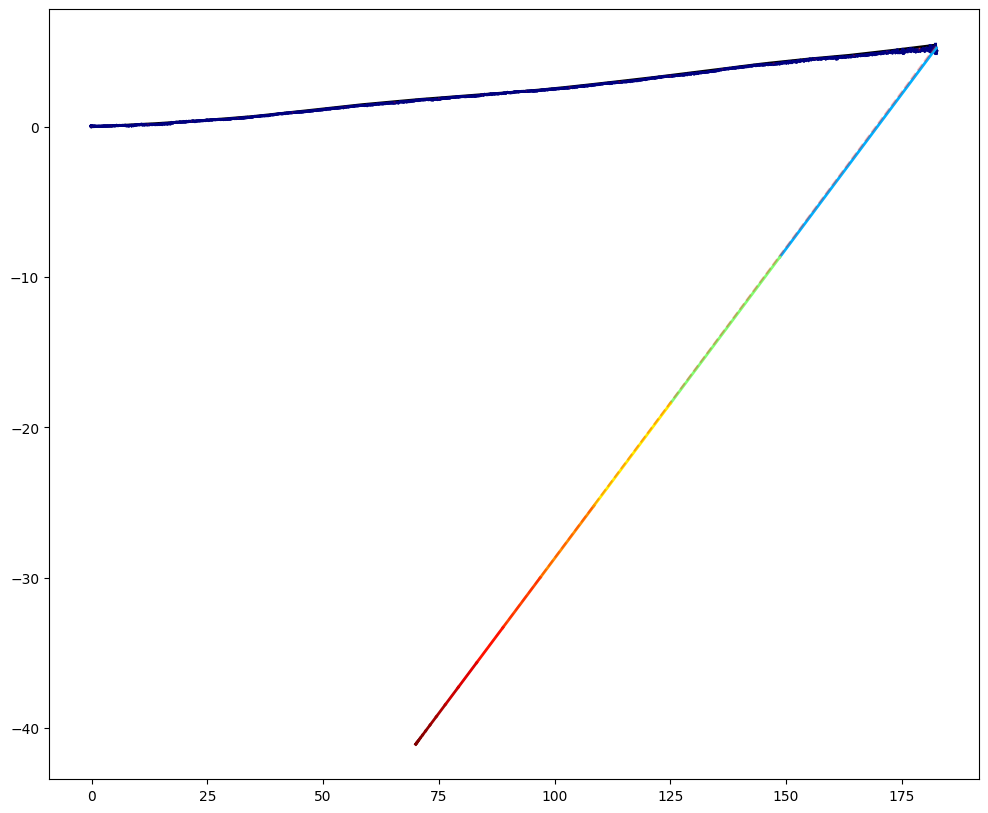

In [57]:
# Alle Frames verarbeiten
results = process_all_frames_improved()

# Ergebnisse speichern
np.save("localization_results.npy", results)

# Trajektorien visualisieren
visualize_trajectory_comparison(results)

# Ausgewählte Frames mit Punktwolken visualisieren
visualize_with_point_clouds(results, sample_frames=[0, 250, 500, 750, 1000])

# Fehlerstatistiken anzeigen
position_errors = [r['position_error'] for r in results]
yaw_errors = [r['yaw_error'] for r in results]

print(f"Durchschnittlicher Positionsfehler: {np.mean(position_errors):.3f} m")
print(f"Maximaler Positionsfehler: {np.max(position_errors):.3f} m")
print(f"Durchschnittlicher Orientierungsfehler: {np.mean(yaw_errors):.3f} rad")
print(f"Maximaler Orientierungsfehler: {np.max(yaw_errors):.3f} rad")


Lade vorhandene Ergebnisse...
=== Fehlerstatistik ===
Durchschnittlicher Fehler: 2.406 m
Median-Fehler: 0.162 m
Minimaler Fehler: 0.005 m
Maximaler Fehler: 121.483 m
Standardabweichung: 15.693 m

=== Die 10 schlechtesten Frames ===
Frame 1013: Fehler = 121.483 m
Frame 1012: Fehler = 121.453 m
Frame 1011: Fehler = 121.412 m
Frame 1010: Fehler = 121.352 m
Frame 1009: Fehler = 121.272 m
Frame 1008: Fehler = 121.149 m
Frame 1007: Fehler = 120.978 m
Frame 1006: Fehler = 120.731 m
Frame 1005: Fehler = 120.380 m
Frame 1004: Fehler = 119.873 m


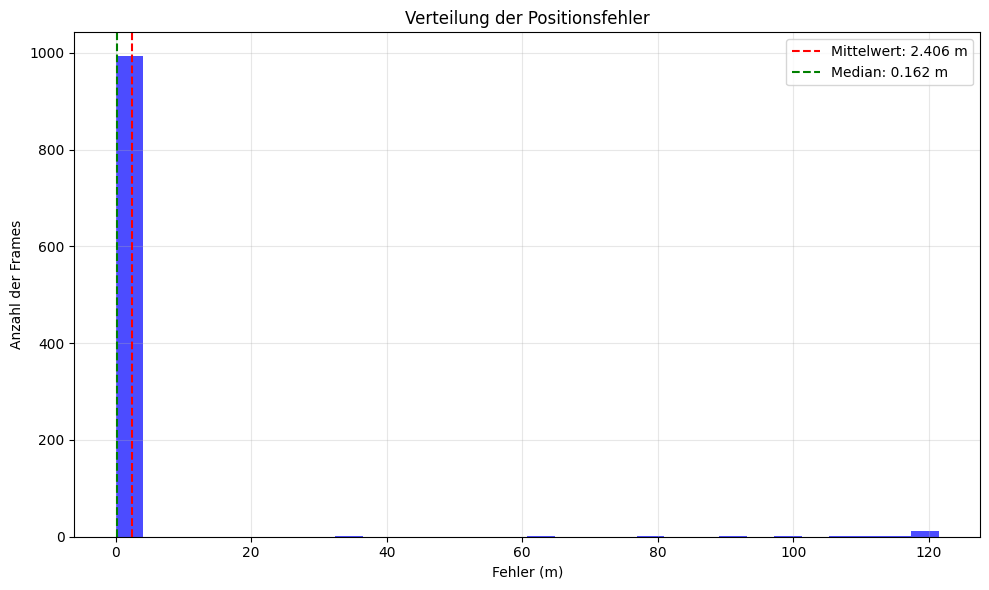

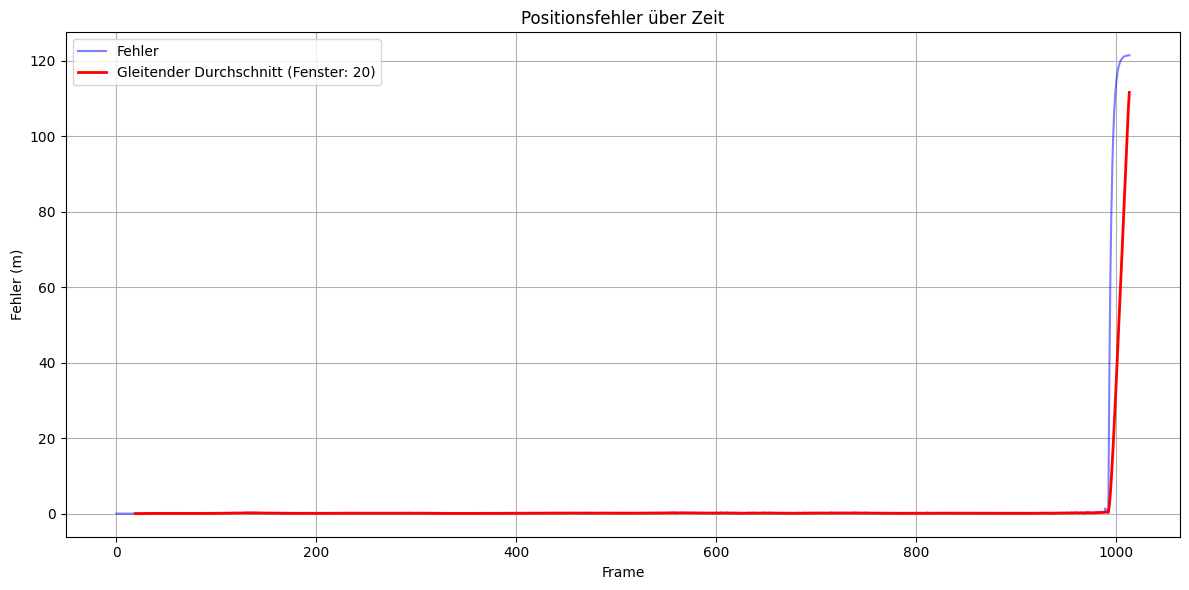

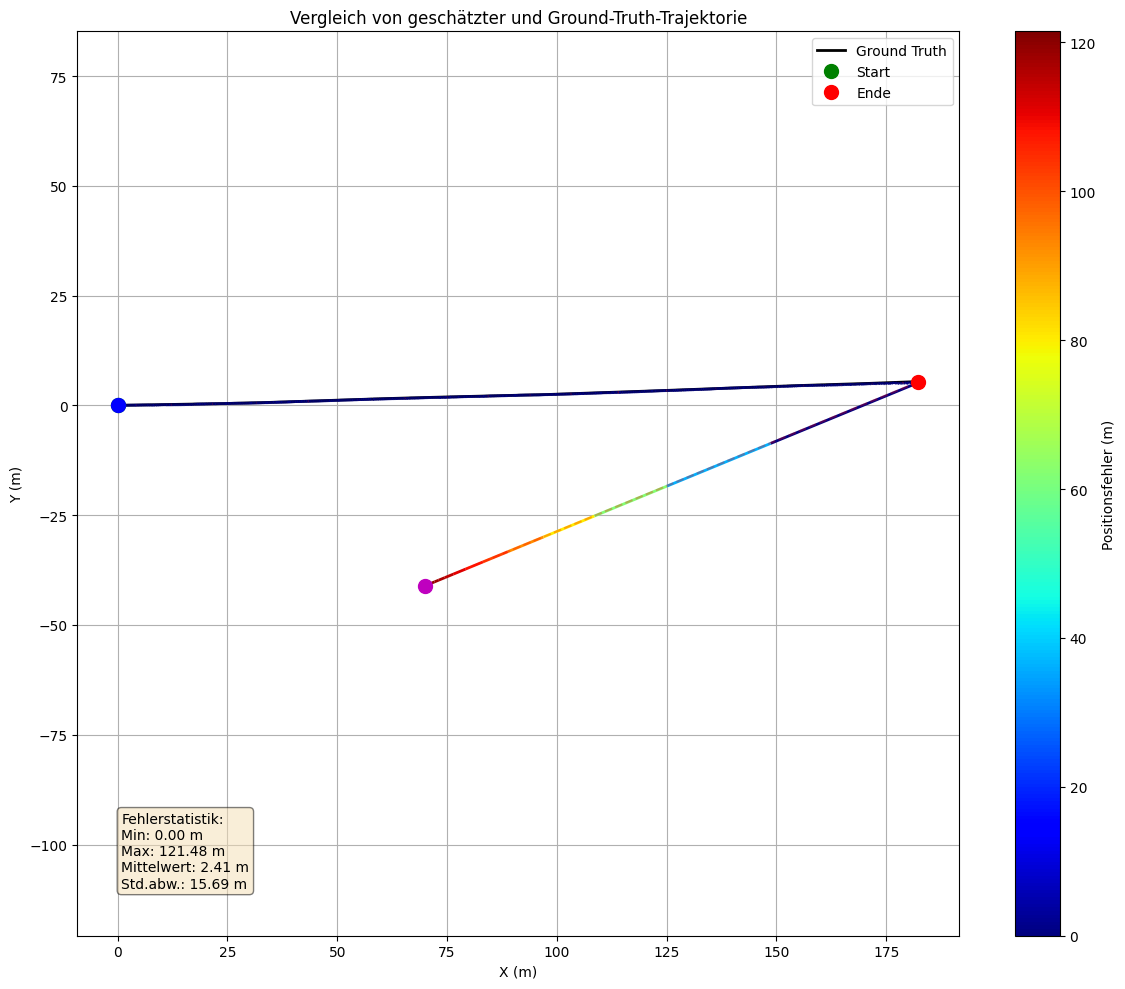

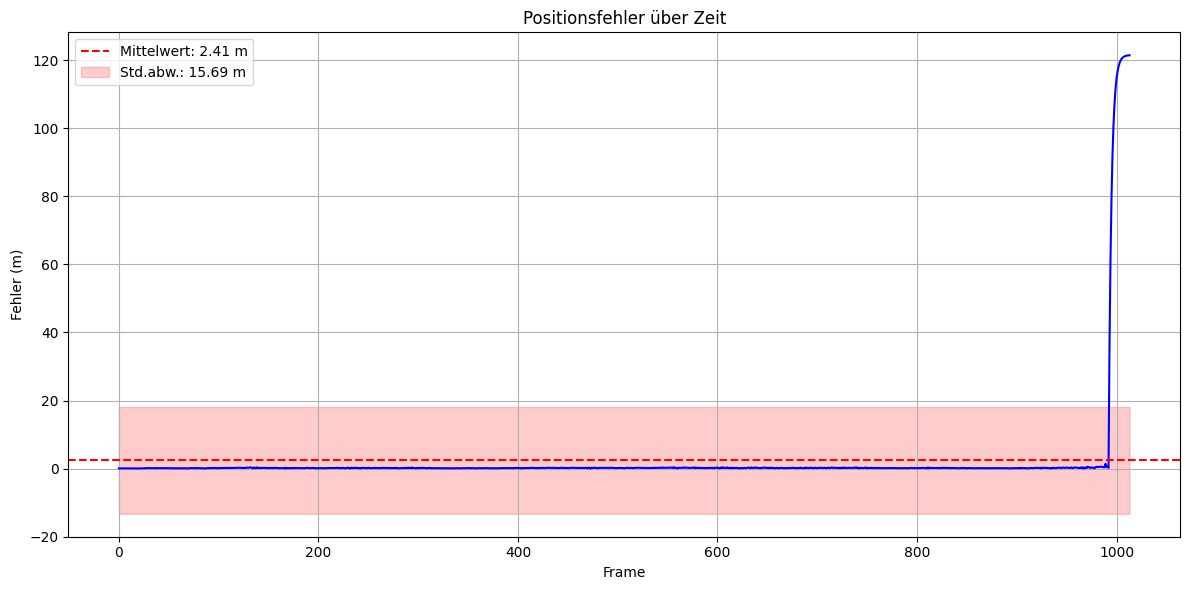


Visualisiere gute Frames...


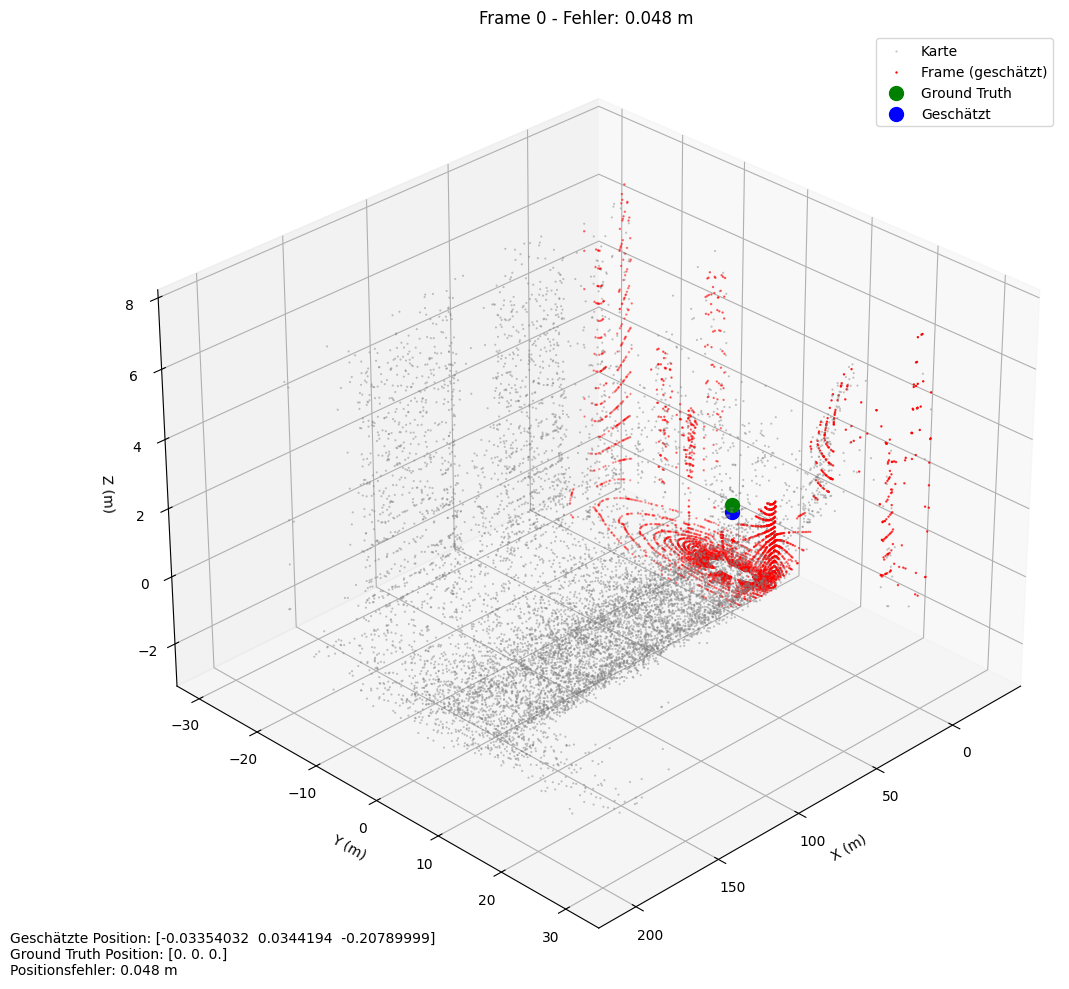

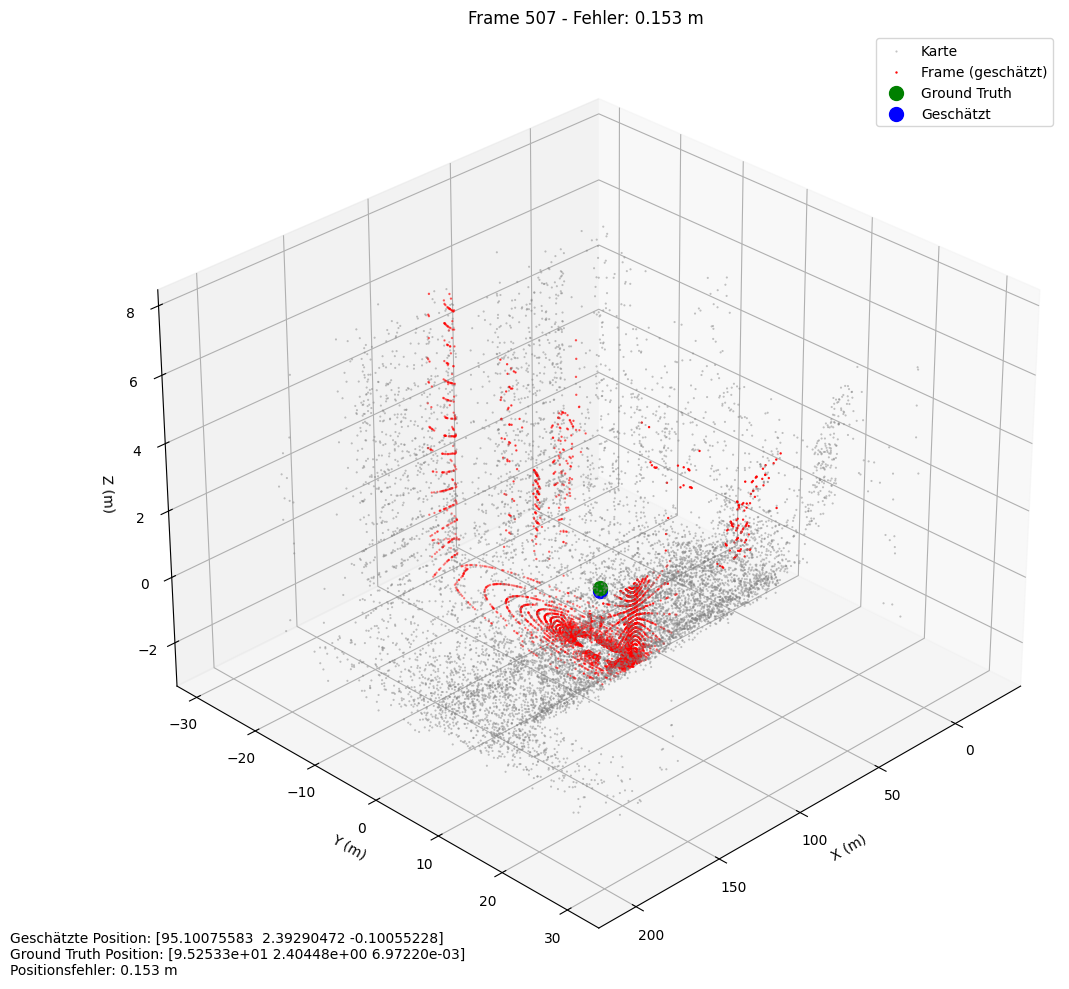

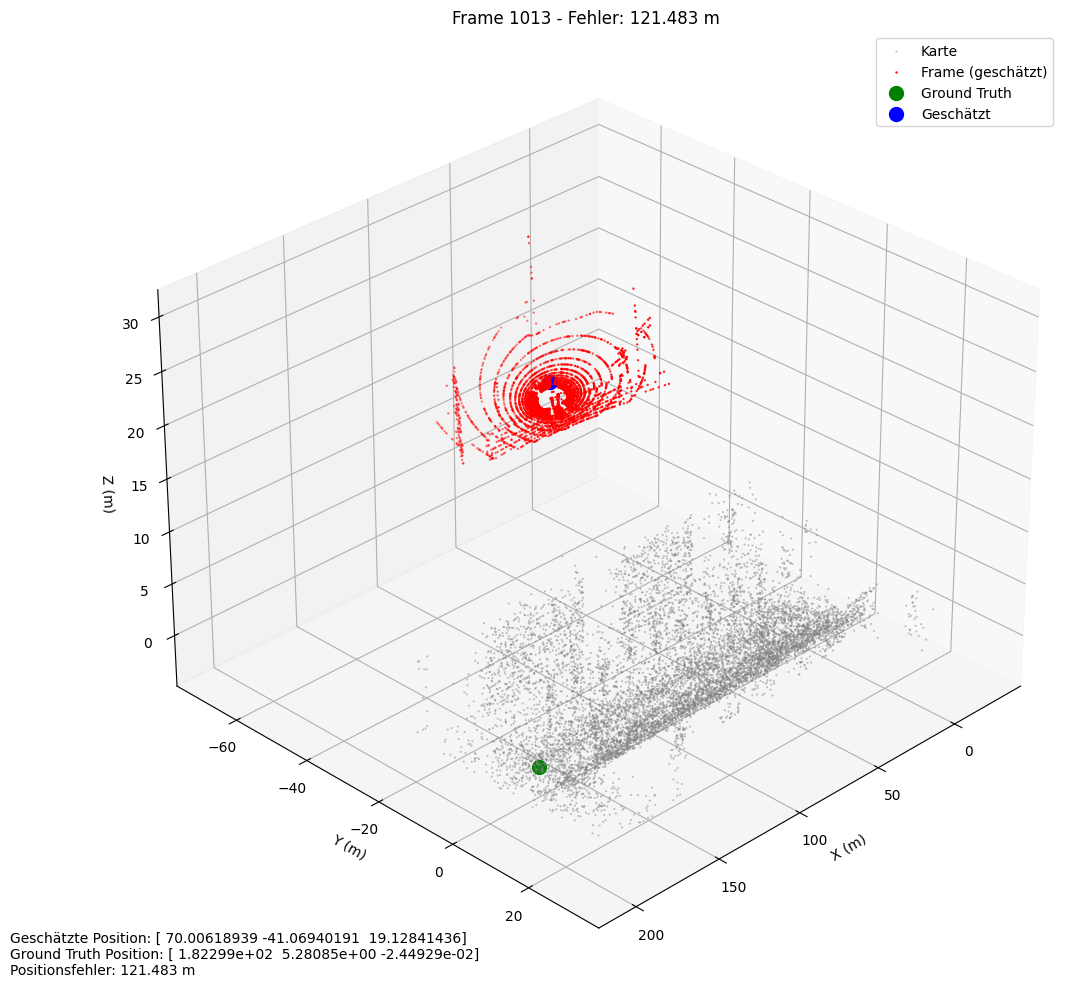


Visualisiere problematische Frames...


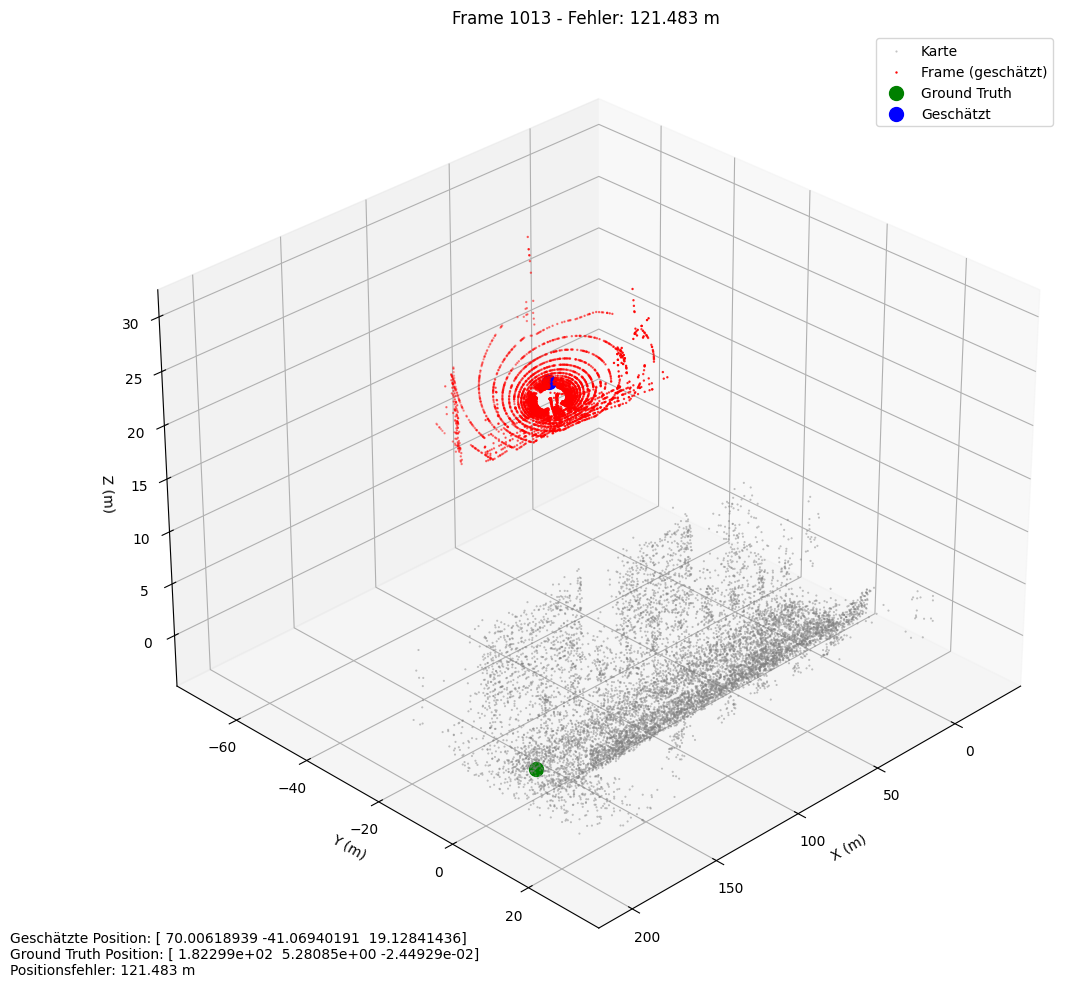

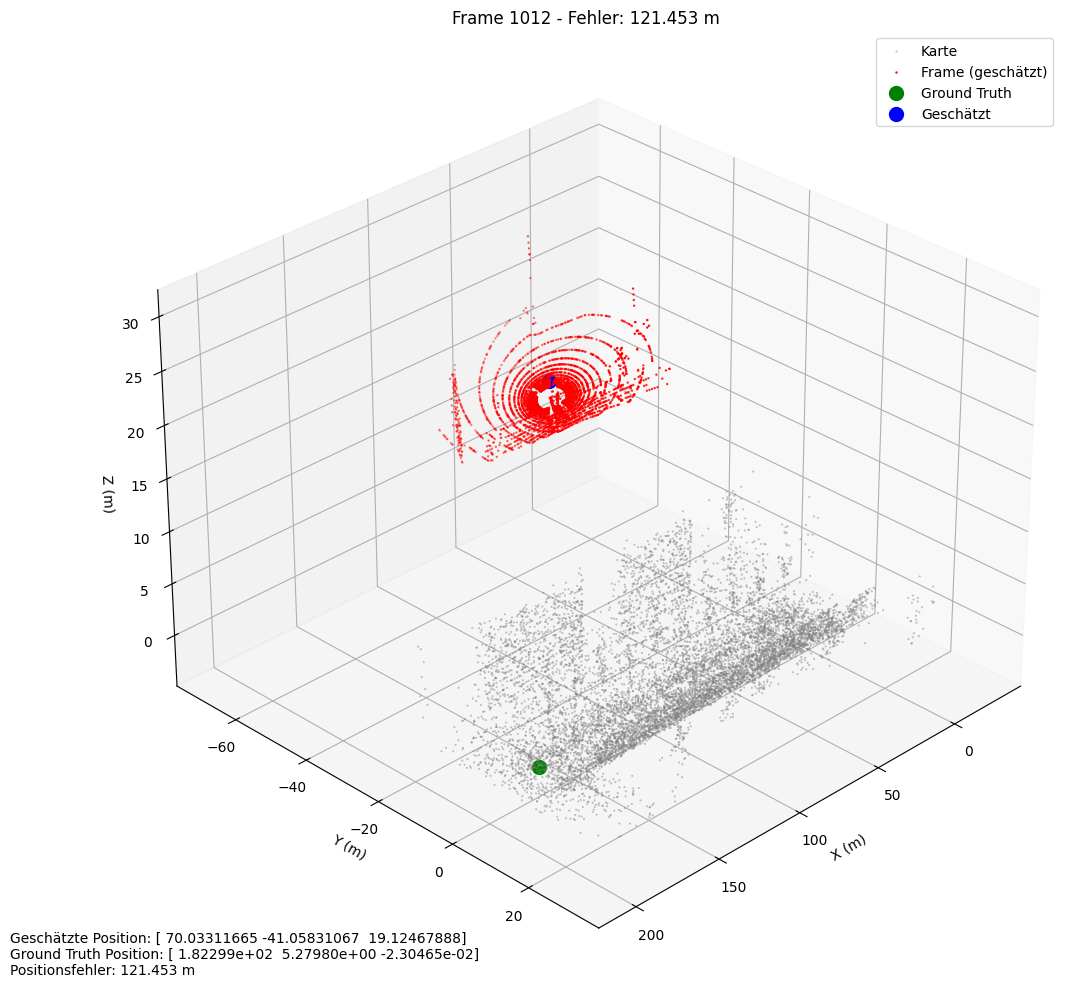

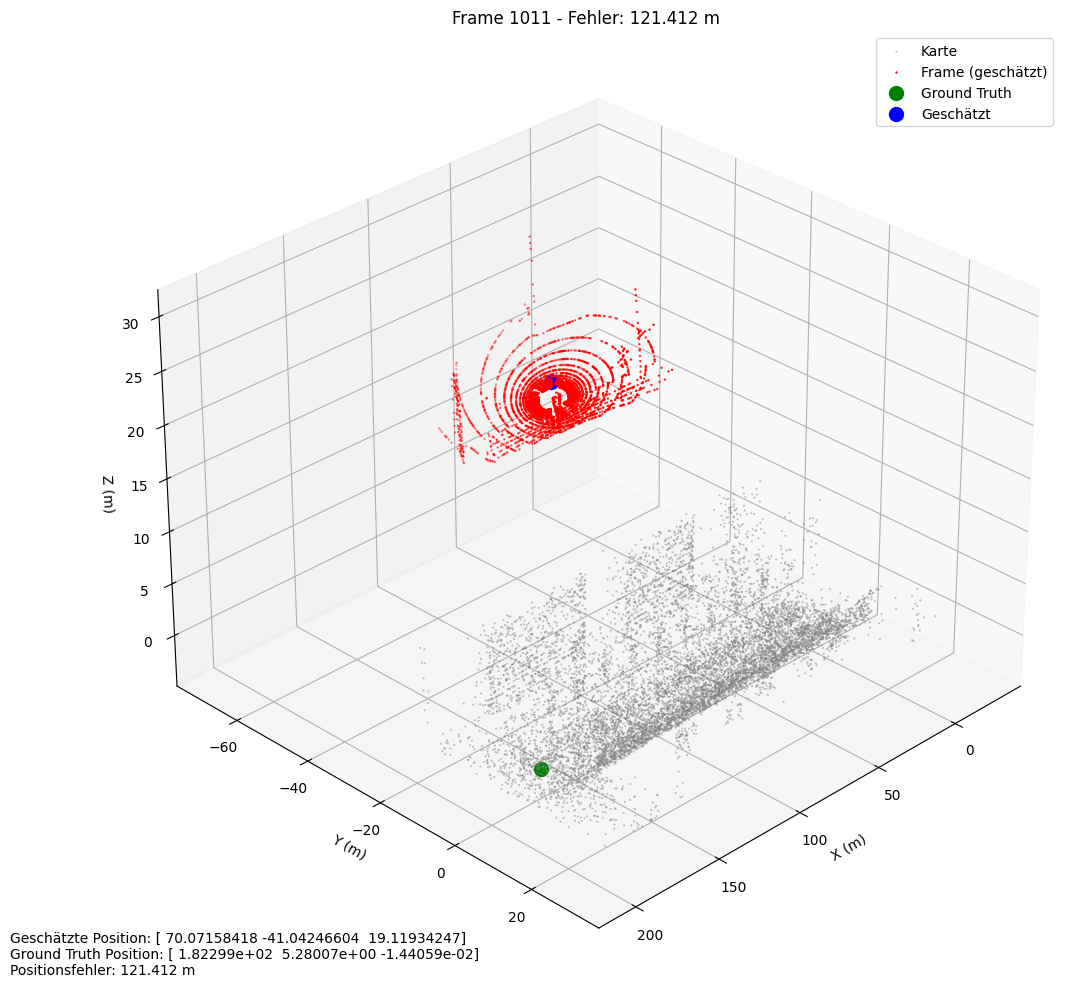

In [62]:
# Importieren der erforderlichen Bibliotheken
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import os
from scipy.spatial.transform import Rotation

# Versuchen, die Ergebnisse zu laden oder zu berechnen
try:
    # Wenn Ergebnisse bereits berechnet wurden, laden
    if os.path.exists("localization_results.npy"):
        print("Lade vorhandene Ergebnisse...")
        results = np.load("localization_results.npy", allow_pickle=True)
        if not isinstance(results, list):
            results = results.tolist()
    else:
        print("Berechne Lokalisierungsergebnisse...")
        results = process_all_frames_improved()
        np.save("localization_results.npy", results)
    
    # Fehleranalyse durchführen
    error_stats = analyze_errors(results)
    
    # Trajektorien visualisieren
    visualize_trajectory_comparison(results)
    
    # Alternative Punktwolkenvisualisierung mit Matplotlib
    worst_frames = error_stats['worst_frames'][:3]  # Die 3 schlechtesten Frames
    good_frames = [0, len(results)//2, len(results)-1]  # Anfang, Mitte, Ende
    
    print("\nVisualisiere gute Frames...")
    visualize_point_clouds_matplotlib(results, good_frames)
    
    print("\nVisualisiere problematische Frames...")
    visualize_point_clouds_matplotlib(results, worst_frames)
    
except Exception as e:
    print(f"Fehler bei der Ausführung: {e}")
    import traceback
    traceback.print_exc()


# 2D Try

In [87]:
def convert_to_2d(point_cloud, height_range=(0.5, 2.0)):
    """
    Reduziert eine 3D-Punktwolke auf 2D, indem nur Punkte in einem bestimmten Höhenbereich
    beibehalten und die Z-Koordinate ignoriert wird.
    
    Args:
        point_cloud: 3D-Punktwolke als numpy-Array [N, 3]
        height_range: Tuple (min_height, max_height) für die Filterung
    
    Returns:
        2D-Punktwolke als numpy-Array [M, 2]
    """
    # Punkte im angegebenen Höhenbereich filtern
    min_height, max_height = height_range
    mask = (point_cloud[:, 2] >= min_height) & (point_cloud[:, 2] <= max_height)
    filtered_points = point_cloud[mask]
    
    # Z-Koordinate entfernen
    points_2d = filtered_points[:, :2]
    print(f"Size of points_2D: {points_2d.shape}")
    #print(f"Durchschnittlicher Positionsfehler: {np.mean(orig_errors):.3f} m")
    return points_2d


In [105]:
def combined_icp_ndt_2d(frame_points_2d, map_points_2d, initial_transform=None, voxel_size=0.5):
    """
    Kombiniert ICP und NDT für eine robustere 2D-Lokalisierung.
    
    Args:
        frame_points_2d: 2D-Punktwolke des aktuellen Frames [N, 2]
        map_points_2d: 2D-Punktwolke der Karte [M, 2]
        initial_transform: Initiale 3x3 Transformationsmatrix (2D homogen)
        voxel_size: Voxelgröße für Downsampling
    
    Returns:
        Beste Transformationsmatrix (3x3) und Fitness-Score
    """
    print(f"combined_icp_ndt_2d shape of initial_transform: {initial_transform.shape}")
    # Punktwolken in Open3D-Format konvertieren (mit Z=0)
    frame_3d = np.hstack((frame_points_2d, np.zeros((frame_points_2d.shape[0], 1))))
    map_3d = np.hstack((map_points_2d, np.zeros((map_points_2d.shape[0], 1))))
    
    frame_pcd = o3d.geometry.PointCloud()
    frame_pcd.points = o3d.utility.Vector3dVector(frame_3d)
    
    map_pcd = o3d.geometry.PointCloud()
    map_pcd.points = o3d.utility.Vector3dVector(map_3d)
    
    # Downsampling für bessere Effizienz
    frame_pcd_down = frame_pcd.voxel_down_sample(voxel_size)
    map_pcd_down = map_pcd.voxel_down_sample(voxel_size)
    
    # Normalen für NDT und Point-to-Plane ICP berechnen
    frame_pcd_down.estimate_normals(search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=voxel_size*2, max_nn=30))
    map_pcd_down.estimate_normals(search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=voxel_size*2, max_nn=30))
    
    # Initiale Transformation (3D aus 2D erstellen)
    if initial_transform is None:
        initial_transform_3d = np.eye(4)
    else:
        # 2D-Transformation in 3D umwandeln
        initial_transform_3d = np.eye(4)
        initial_transform_3d[:2, :2] = initial_transform[:2, :2]
        initial_transform_3d[:2, 3] = initial_transform[:2, 3]
    
    # ICP-Registrierung durchführen (Point-to-Point)
    icp_result = o3d.pipelines.registration.registration_icp(
        frame_pcd_down, map_pcd_down, 
        max_correspondence_distance=voxel_size*2,
        init=initial_transform_3d,
        estimation_method=o3d.pipelines.registration.TransformationEstimationPointToPoint(),
        criteria=o3d.pipelines.registration.ICPConvergenceCriteria(max_iteration=100)
    )
    
    # ICP-Registrierung durchführen (Point-to-Plane für bessere Genauigkeit)
    icp_plane_result = o3d.pipelines.registration.registration_icp(
        frame_pcd_down, map_pcd_down, 
        max_correspondence_distance=voxel_size*2,
        init=initial_transform_3d,
        estimation_method=o3d.pipelines.registration.TransformationEstimationPointToPlane(),
        criteria=o3d.pipelines.registration.ICPConvergenceCriteria(max_iteration=100)
    )
    
    # NDT-Registrierung durchführen
    ndt_param = o3d.pipelines.registration.TransformationEstimationPointToPoint()
    ndt_result = o3d.pipelines.registration.registration_ndt(
        frame_pcd_down, map_pcd_down,
        resolution=voxel_size*4,  # NDT braucht größere Voxel
        init=initial_transform_3d,
        criteria=o3d.pipelines.registration.ICPConvergenceCriteria(max_iteration=50)
    )
    
    # Ergebnisse vergleichen und das beste auswählen
    results = [
        (icp_result, "ICP Point-to-Point"),
        (icp_plane_result, "ICP Point-to-Plane"),
        (ndt_result, "NDT")
    ]
    
    # Nach Fitness sortieren (höher ist besser)
    results.sort(key=lambda x: x[0].fitness, reverse=True)
    
    best_result, method_name = results[0]
    
    print(f"Bester Algorithmus: {method_name} (Fitness: {best_result.fitness:.4f}, RMSE: {best_result.inlier_rmse:.4f})")
    
    # Transformation auf 2D reduzieren
    transform_3d = best_result.transformation
    transform_2d = np.eye(3)
    transform_2d[:2, :2] = transform_3d[:2, :2]
    transform_2d[:2, 2] = transform_3d[:2, 3]
    
    return transform_2d, best_result.fitness


In [91]:
def localize_vehicle_2d(map_path, frames_dir, ground_truth_path):
    """
    Lokalisiert das Fahrzeug mit einem 2D-Ansatz und kombiniertem ICP/NDT.
    
    Args:
        map_path: Pfad zur Kartenpunktwolke
        frames_dir: Verzeichnis mit den Frame-Punktwolken
        ground_truth_path: Pfad zur Ground-Truth-CSV-Datei
    
    Returns:
        Liste mit Lokalisierungsergebnissen
    """
    # Ground-Truth-Daten laden
    gts = pd.read_csv(ground_truth_path)
    
    # Karte laden und auf 2D reduzieren
    map_array = pcd_from_path(map_path)
    map_2d = convert_to_2d(map_array, height_range=(0.5, 2.0))
    
    # Ergebnisse speichern
    results = []
    
    # Initialisierung
    prev_transform = np.eye(3)  # 2D homogene Transformation
    prev_velocity = np.zeros(3)  # [vx, vy, omega]
    
    # Kalman-Filter für Glättung initialisieren
    kf = SimpleKalmanFilter2D()
    
    # Alle Frames verarbeiten
    frame_files = sorted([f for f in os.listdir(frames_dir) if f.startswith("frame_") and f.endswith(".pcd")])
    
    for i, frame_file in enumerate(frame_files):
        frame_num = int(frame_file.split("_")[1].split(".")[0])
        print(f"Verarbeite Frame {frame_num} ({i+1}/{len(frame_files)})")
        
        try:
            # Frame laden und auf 2D reduzieren
            frame_path = os.path.join(frames_dir, frame_file)
            frame_array = pcd_from_path(frame_path)
            frame_2d = convert_to_2d(frame_array, height_range=(0.5, 2.0))
            
            # Kalman-Filter-Vorhersage für bessere Initialisierung
            predicted_state = kf.predict()
            
            # Bewegungsmodell für bessere Initialisierung
            if i > 0:
                # Einfaches Bewegungsmodell basierend auf vorherigen Frames
                motion_prediction = np.eye(3)
                motion_prediction[:2, 2] = prev_transform[:2, 2] + prev_velocity[:2]
                
                # Gewichtete Kombination aus Bewegungsmodell und Kalman-Vorhersage
                alpha = 0.7  # Gewichtung
                initial_guess = np.eye(3)
                initial_guess[:2, :2] = prev_transform[:2, :2]
                initial_guess[:2, 2] = alpha * motion_prediction[:2, 2] + (1-alpha) * np.array([predicted_state[0], predicted_state[1]])
            else:
                initial_guess = np.eye(3)
            
            # Lokalisierung mit kombiniertem ICP und NDT
            transform_2d, fitness = combined_icp_ndt_2d(
                frame_2d, 
                map_2d, 
                initial_transform=initial_guess,
                voxel_size=0.25
            )
            
            # Geschwindigkeit aktualisieren
            if i > 0:
                current_pos = transform_2d[:2, 2]
                prev_pos = prev_transform[:2, 2]
                prev_velocity[:2] = (current_pos - prev_pos)
                
                # Rotationsänderung berechnen
                current_angle = np.arctan2(transform_2d[1, 0], transform_2d[0, 0])
                prev_angle = np.arctan2(prev_transform[1, 0], prev_transform[0, 0])
                prev_velocity[2] = (current_angle - prev_angle)
            
            prev_transform = transform_2d
            
            # Geschätzte Position und Orientierung extrahieren
            estimated_pos_2d = transform_2d[:2, 2]
            estimated_angle = np.arctan2(transform_2d[1, 0], transform_2d[0, 0])
            
            # In 3D umwandeln für Vergleich mit Ground Truth
            estimated_pos = np.array([estimated_pos_2d[0], estimated_pos_2d[1], 0.0])
            estimated_orientation = np.array([0.0, 0.0, estimated_angle])
            
            # Ground-Truth-Werte abrufen
            gt_row = gts.iloc[frame_num]
            gt_pos = np.array([gt_row[1], gt_row[2], gt_row[3]])  # x, y, z
            gt_orientation = np.array([gt_row[4], gt_row[5], gt_row[6]])  # roll, pitch, yaw
            
            # Kalman-Filter-Update
            measurement = np.array([estimated_pos_2d[0], estimated_pos_2d[1], estimated_angle])
            filtered_state = kf.update(measurement)
            
            # Fehler berechnen
            position_error_2d = np.linalg.norm(estimated_pos_2d - gt_pos[:2])
            yaw_error = np.abs(gt_orientation[2] - estimated_angle)
            yaw_error = min(yaw_error, 2*np.pi - yaw_error)  # Berücksichtigung der Periodizität
            
            # Ergebnisse speichern
            results.append({
                'frame': frame_num,
                'estimated_pos': estimated_pos,
                'estimated_pos_2d': estimated_pos_2d,
                'estimated_orientation': estimated_orientation,
                'estimated_angle': estimated_angle,
                'filtered_pos_2d': filtered_state[:2],
                'filtered_angle': filtered_state[2],
                'gt_pos': gt_pos,
                'gt_orientation': gt_orientation,
                'position_error': position_error_2d,
                'yaw_error': yaw_error,
                'transform_2d': transform_2d,
                'fitness': fitness
            })
            
        except Exception as e:
            print(f"localize_vehicle_2d Fehler bei Frame {frame_num}: {e}")
            import traceback
            traceback.print_exc()
            
            # Wenn ein Frame fehlschlägt, vorherigen Zustand beibehalten
            if i > 0 and results:
                last_result = results[-1].copy()
                last_result['frame'] = frame_num
                results.append(last_result)
    
    return results


In [66]:
class SimpleKalmanFilter2D:
    def __init__(self, process_noise=0.01, measurement_noise=0.1):
        # Zustandsvektor: [x, y, theta, vx, vy, omega]
        self.state = np.zeros(6)
        self.P = np.eye(6)  # Kovarianzmatrix
        self.Q = np.eye(6) * process_noise  # Prozessrauschen
        self.R = np.eye(3) * measurement_noise  # Messrauschen
        
    def predict(self, dt=1.0):
        # Einfaches Bewegungsmodell: Position += Geschwindigkeit * dt
        F = np.eye(6)
        F[0, 3] = dt  # x += vx * dt
        F[1, 4] = dt  # y += vy * dt
        F[2, 5] = dt  # theta += omega * dt
        
        # Zustand vorhersagen
        self.state = F @ self.state
        
        # Winkel normalisieren
        self.state[2] = np.mod(self.state[2], 2*np.pi)
        
        # Kovarianz aktualisieren
        self.P = F @ self.P @ F.T + self.Q
        
        return self.state[:3]  # Nur Position und Orientierung zurückgeben
    
    def update(self, measurement):
        # Measurement: [x, y, theta]
        H = np.zeros((3, 6))
        H[:3, :3] = np.eye(3)  # Messmatrix
        
        # Kalman-Gain berechnen
        S = H @ self.P @ H.T + self.R
        K = self.P @ H.T @ np.linalg.inv(S)
        
        # Winkelunterschied berechnen (Berücksichtigung der Periodizität)
        y = measurement - H @ self.state
        y[2] = np.mod(y[2] + np.pi, 2*np.pi) - np.pi  # Winkelunterschied normalisieren
        
        # Zustand aktualisieren
        self.state = self.state + K @ y
        
        # Winkel normalisieren
        self.state[2] = np.mod(self.state[2], 2*np.pi)
        
        # Kovarianz aktualisieren
        self.P = (np.eye(6) - K @ H) @ self.P
        
        return self.state[:3]  # Nur Position und Orientierung zurückgeben


In [67]:
def visualize_2d_trajectory(results):
    """
    Visualisiert die 2D-Trajektorien mit Fehlerfarben
    """
    plt.figure(figsize=(12, 10))
    
    # Daten extrahieren
    frames = [r['frame'] for r in results]
    gt_x = [r['gt_pos'][0] for r in results]
    gt_y = [r['gt_pos'][1] for r in results]
    est_x = [r['estimated_pos_2d'][0] for r in results]
    est_y = [r['estimated_pos_2d'][1] for r in results]
    filtered_x = [r['filtered_pos_2d'][0] for r in results]
    filtered_y = [r['filtered_pos_2d'][1] for r in results]
    errors = [r['position_error'] for r in results]
    
    # Ground Truth Trajektorie plotten
    plt.plot(gt_x, gt_y, 'k-', linewidth=2, label='Ground Truth')
    
    # Gefilterte Trajektorie plotten
    plt.plot(filtered_x, filtered_y, 'g-', linewidth=1.5, label='Gefiltert (Kalman)')
    
    # Geschätzte Trajektorie mit Fehlerfarben plotten
    points = np.array([est_x, est_y]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    
    cmap = plt.cm.jet
    norm = plt.Normalize(0, max(errors))
    lc = matplotlib.collections.LineCollection(segments, cmap=cmap, norm=norm)
    lc.set_array(np.array(errors))
    lc.set_linewidth(2)
    line = plt.gca().add_collection(lc)
    
    # Verbindungslinien zwischen geschätzter und Ground-Truth-Position
    for i in range(0, len(frames), 50):  # Alle 50 Frames
        plt.plot([gt_x[i], est_x[i]], [gt_y[i], est_y[i]], 'r--', alpha=0.3)
    
    # Start- und Endpunkte markieren
    plt.plot(gt_x[0], gt_y[0], 'go', markersize=10, label='Start')
    plt.plot(est_x[0], est_y[0], 'bo', markersize=8)
    plt.plot(gt_x[-1], gt_y[-1], 'ro', markersize=10, label='Ende')
    plt.plot(est_x[-1], est_y[-1], 'mo', markersize=8)
    
    # Farbbalken für Fehler
    cbar = plt.colorbar(line)
    cbar.set_label('Positionsfehler (m)')
    
    # Achsen und Titel
    plt.title('2D-Lokalisierung: Vergleich der Trajektorien')
    plt.xlabel('X (m)')
    plt.ylabel('Y (m)')
    plt.legend()
    plt.grid(True)
    plt.axis('equal')
    
    # Fehlerstatistik anzeigen
    avg_error = np.mean(errors)
    max_error = np.max(errors)
    min_error = np.min(errors)
    std_error = np.std(errors)
    
    stats_text = (f'Fehlerstatistik:\n'
                 f'Min: {min_error:.2f} m\n'
                 f'Max: {max_error:.2f} m\n'
                 f'Mittelwert: {avg_error:.2f} m\n'
                 f'Std.abw.: {std_error:.2f} m')
    
    # Text in einer Box anzeigen
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
    plt.text(0.05, 0.05, stats_text, transform=plt.gca().transAxes, fontsize=10,
            verticalalignment='bottom', bbox=props)
    
    plt.tight_layout()
    plt.show()


In [68]:
def visualize_2d_point_clouds(results, map_path, frames_dir, sample_frames=[0, 250, 500, 750, 1000]):
    """
    Visualisiert die 2D-Punktwolken für ausgewählte Frames
    """
    # Karte laden und auf 2D reduzieren
    map_array = pcd_from_path(map_path)
    map_2d = convert_to_2d(map_array, height_range=(0.5, 2.0))
    
    for frame_num in sample_frames:
        if frame_num >= len(results):
            continue
            
        result = results[frame_num]
        transform_2d = result['transform_2d']
        
        # Frame laden und auf 2D reduzieren
        frame_path = os.path.join(frames_dir, f"frame_{frame_num}.pcd")
        frame_array = pcd_from_path(frame_path)
        frame_2d = convert_to_2d(frame_array, height_range=(0.5, 2.0))
        
        # Frame transformieren
        homogeneous_frame = np.hstack((frame_2d, np.ones((frame_2d.shape[0], 1))))
        transformed_frame = (transform_2d @ homogeneous_frame.T).T[:, :2]
        
        # Visualisierung
        plt.figure(figsize=(12, 10))
        
        # Karte plotten (mit Downsampling für bessere Performance)
        sample_size = min(10000, map_2d.shape[0])
        sample_indices = np.random.choice(map_2d.shape[0], sample_size, replace=False)
        plt.scatter(map_2d[sample_indices, 0], map_2d[sample_indices, 1], 
                   c='gray', marker='.', s=1, alpha=0.5, label='Karte')
        
        # Transformierten Frame plotten
        plt.scatter(transformed_frame[:, 0], transformed_frame[:, 1], 
                   c='red', marker='.', s=2, alpha=0.7, label='Frame (geschätzt)')
        
        # Ground Truth Position plotten
        gt_pos = result['gt_pos'][:2]
        plt.scatter(gt_pos[0], gt_pos[1], c='green', marker='o', s=100, label='Ground Truth')
        
        # Geschätzte Position plotten
        est_pos = result['estimated_pos_2d']
        plt.scatter(est_pos[0], est_pos[1], c='blue', marker='o', s=100, label='Geschätzt')
        
        # Gefilterte Position plotten
        filtered_pos = result['filtered_pos_2d']
        plt.scatter(filtered_pos[0], filtered_pos[1], c='purple', marker='o', s=100, label='Gefiltert')
        
        # Orientierungen anzeigen
        arrow_length = 2.0
        
        # Ground Truth Orientierung
        gt_angle = result['gt_orientation'][2]
        plt.arrow(gt_pos[0], gt_pos[1], 
                 arrow_length * np.cos(gt_angle), arrow_length * np.sin(gt_angle),
                 head_width=0.5, head_length=0.7, fc='green', ec='green')
        
        # Geschätzte Orientierung
        est_angle = result['estimated_angle']
        plt.arrow(est_pos[0], est_pos[1], 
                 arrow_length * np.cos(est_angle), arrow_length * np.sin(est_angle),
                 head_width=0.5, head_length=0.7, fc='blue', ec='blue')
        
        # Achsenbeschriftungen und Titel
        plt.title(f'Frame {frame_num} - Fehler: {result["position_error"]:.3f} m')
        plt.xlabel('X (m)')
        plt.ylabel('Y (m)')
        plt.legend()
        plt.grid(True)
        plt.axis('equal')
        
        # Statistik anzeigen
        info_text = (f"Geschätzte Position: ({est_pos[0]:.2f}, {est_pos[1]:.2f})\n"
                    f"Ground Truth Position: ({gt_pos[0]:.2f}, {gt_pos[1]:.2f})\n"
                    f"Positionsfehler: {result['position_error']:.3f} m\n"
                    f"Orientierungsfehler: {result['yaw_error']:.3f} rad\n"
                    f"Fitness-Score: {result['fitness']:.4f}")
        
        props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
        plt.text(0.02, 0.02, info_text, transform=plt.gca().transAxes, fontsize=10,
                verticalalignment='bottom', bbox=props)
        
        plt.tight_layout()
        plt.show()


In [69]:
def main():
    """
    Hauptfunktion zur Ausführung der 2D-Lokalisierung
    """
    # Pfade definieren
    map_path = "./dataset/map.pcd"
    frames_dir = "./dataset/frames"
    ground_truth_path = "./dataset/ground_truth.csv"
    
    # Prüfen, ob bereits Ergebnisse vorhanden sind
    results_path = "localization_results_2d.npy"
    
    if os.path.exists(results_path):
        print(f"Lade vorhandene Ergebnisse aus {results_path}...")
        results = np.load(results_path, allow_pickle=True).tolist()
    else:
        print("Starte 2D-Lokalisierung...")
        results = localize_vehicle_2d(map_path, frames_dir, ground_truth_path)
        np.save(results_path, results)
    
    # Ergebnisse analysieren
    errors = [r['position_error'] for r in results]
    yaw_errors = [r['yaw_error'] for r in results]
    
    print("\n=== Fehlerstatistik ===")
    print(f"Durchschnittlicher Positionsfehler: {np.mean(errors):.3f} m")
    print(f"Median-Positionsfehler: {np.median(errors):.3f} m")
    print(f"Maximaler Positionsfehler: {np.max(errors):.3f} m")
    print(f"Minimaler Positionsfehler: {np.min(errors):.3f} m")
    print(f"Standardabweichung: {np.std(errors):.3f} m")
    print(f"Durchschnittlicher Orientierungsfehler: {np.mean(yaw_errors):.3f} rad")
    
    # Trajektorie visualisieren
    visualize_2d_trajectory(results)
    
    # Punktwolken für ausgewählte Frames visualisieren
    # Beste Frames finden
    best_indices = np.argsort(errors)[:3]
    best_frames = [results[i]['frame'] for i in best_indices]
    
    # Schlechteste Frames finden
    worst_indices = np.argsort(errors)[-3:]
    worst_frames = [results[i]['frame'] for i in worst_indices]
    
    print("\nVisualisiere beste Frames:", best_frames)
    visualize_2d_point_clouds(results, map_path, frames_dir, best_frames)
    
    print("\nVisualisiere schlechteste Frames:", worst_frames)
    visualize_2d_point_clouds(results, map_path, frames_dir, worst_frames)
    
    # Weitere Frames zur Visualisierung
    key_frames = [0, len(results)//4, len(results)//2, 3*len(results)//4, len(results)-1]
    print("\nVisualisiere Schlüssel-Frames:", key_frames)
    visualize_2d_point_clouds(results, map_path, frames_dir, key_frames)

if __name__ == "__main__":
    main()


Starte 2D-Lokalisierung...
Verarbeite Frame 0 (1/1014)
Fehler bei Frame 0: index 3 is out of bounds for axis 1 with size 3
Verarbeite Frame 1 (2/1014)
Fehler bei Frame 1: index 3 is out of bounds for axis 1 with size 3
Verarbeite Frame 10 (3/1014)
Fehler bei Frame 10: index 3 is out of bounds for axis 1 with size 3
Verarbeite Frame 100 (4/1014)
Fehler bei Frame 100: index 3 is out of bounds for axis 1 with size 3
Verarbeite Frame 1000 (5/1014)
Fehler bei Frame 1000: index 3 is out of bounds for axis 1 with size 3
Verarbeite Frame 1001 (6/1014)
Fehler bei Frame 1001: index 3 is out of bounds for axis 1 with size 3
Verarbeite Frame 1002 (7/1014)
Fehler bei Frame 1002: index 3 is out of bounds for axis 1 with size 3
Verarbeite Frame 1003 (8/1014)
Fehler bei Frame 1003: index 3 is out of bounds for axis 1 with size 3
Verarbeite Frame 1004 (9/1014)
Fehler bei Frame 1004: index 3 is out of bounds for axis 1 with size 3
Verarbeite Frame 1005 (10/1014)
Fehler bei Frame 1005: index 3 is out of 

Traceback (most recent call last):
  File "C:\Users\danie\AppData\Local\Temp\ipykernel_6796\3616695395.py", line 61, in localize_vehicle_2d
    transform_2d, fitness = combined_icp_ndt_2d(
                            ^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\danie\AppData\Local\Temp\ipykernel_6796\2816266273.py", line 39, in combined_icp_ndt_2d
    initial_transform_3d[:2, 3] = initial_transform[:2, 3]
                                  ~~~~~~~~~~~~~~~~~^^^^^^^
IndexError: index 3 is out of bounds for axis 1 with size 3
Traceback (most recent call last):
  File "C:\Users\danie\AppData\Local\Temp\ipykernel_6796\3616695395.py", line 61, in localize_vehicle_2d
    transform_2d, fitness = combined_icp_ndt_2d(
                            ^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\danie\AppData\Local\Temp\ipykernel_6796\2816266273.py", line 39, in combined_icp_ndt_2d
    initial_transform_3d[:2, 3] = initial_transform[:2, 3]
                                  ~~~~~~~~~~~~~~~~~^^^^^^^
IndexError: index 

Fehler bei Frame 1009: index 3 is out of bounds for axis 1 with size 3
Verarbeite Frame 101 (15/1014)
Fehler bei Frame 101: index 3 is out of bounds for axis 1 with size 3
Verarbeite Frame 1010 (16/1014)
Fehler bei Frame 1010: index 3 is out of bounds for axis 1 with size 3
Verarbeite Frame 1011 (17/1014)
Fehler bei Frame 1011: index 3 is out of bounds for axis 1 with size 3
Verarbeite Frame 1012 (18/1014)
Fehler bei Frame 1012: index 3 is out of bounds for axis 1 with size 3
Verarbeite Frame 1013 (19/1014)
Fehler bei Frame 1013: index 3 is out of bounds for axis 1 with size 3
Verarbeite Frame 102 (20/1014)
Fehler bei Frame 102: index 3 is out of bounds for axis 1 with size 3
Verarbeite Frame 103 (21/1014)
Fehler bei Frame 103: index 3 is out of bounds for axis 1 with size 3
Verarbeite Frame 104 (22/1014)
Fehler bei Frame 104: index 3 is out of bounds for axis 1 with size 3
Verarbeite Frame 105 (23/1014)
Fehler bei Frame 105: index 3 is out of bounds for axis 1 with size 3
Verarbeite F

Traceback (most recent call last):
  File "C:\Users\danie\AppData\Local\Temp\ipykernel_6796\3616695395.py", line 61, in localize_vehicle_2d
    transform_2d, fitness = combined_icp_ndt_2d(
                            ^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\danie\AppData\Local\Temp\ipykernel_6796\2816266273.py", line 39, in combined_icp_ndt_2d
    initial_transform_3d[:2, 3] = initial_transform[:2, 3]
                                  ~~~~~~~~~~~~~~~~~^^^^^^^
IndexError: index 3 is out of bounds for axis 1 with size 3
Traceback (most recent call last):
  File "C:\Users\danie\AppData\Local\Temp\ipykernel_6796\3616695395.py", line 61, in localize_vehicle_2d
    transform_2d, fitness = combined_icp_ndt_2d(
                            ^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\danie\AppData\Local\Temp\ipykernel_6796\2816266273.py", line 39, in combined_icp_ndt_2d
    initial_transform_3d[:2, 3] = initial_transform[:2, 3]
                                  ~~~~~~~~~~~~~~~~~^^^^^^^
IndexError: index 

Fehler bei Frame 113: index 3 is out of bounds for axis 1 with size 3
Verarbeite Frame 114 (33/1014)
Fehler bei Frame 114: index 3 is out of bounds for axis 1 with size 3
Verarbeite Frame 115 (34/1014)
Fehler bei Frame 115: index 3 is out of bounds for axis 1 with size 3
Verarbeite Frame 116 (35/1014)
Fehler bei Frame 116: index 3 is out of bounds for axis 1 with size 3
Verarbeite Frame 117 (36/1014)
Fehler bei Frame 117: index 3 is out of bounds for axis 1 with size 3
Verarbeite Frame 118 (37/1014)
Fehler bei Frame 118: index 3 is out of bounds for axis 1 with size 3
Verarbeite Frame 119 (38/1014)
Fehler bei Frame 119: index 3 is out of bounds for axis 1 with size 3
Verarbeite Frame 12 (39/1014)
Fehler bei Frame 12: index 3 is out of bounds for axis 1 with size 3
Verarbeite Frame 120 (40/1014)
Fehler bei Frame 120: index 3 is out of bounds for axis 1 with size 3
Verarbeite Frame 121 (41/1014)
Fehler bei Frame 121: index 3 is out of bounds for axis 1 with size 3
Verarbeite Frame 122 (4

...

Fehler bei Frame 965: index 3 is out of bounds for axis 1 with size 3
Verarbeite Frame 966 (978/1014)
Fehler bei Frame 966: index 3 is out of bounds for axis 1 with size 3
Verarbeite Frame 967 (979/1014)
Fehler bei Frame 967: index 3 is out of bounds for axis 1 with size 3
Verarbeite Frame 968 (980/1014)
Fehler bei Frame 968: index 3 is out of bounds for axis 1 with size 3
Verarbeite Frame 969 (981/1014)
Fehler bei Frame 969: index 3 is out of bounds for axis 1 with size 3
Verarbeite Frame 97 (982/1014)
Fehler bei Frame 97: index 3 is out of bounds for axis 1 with size 3
Verarbeite Frame 970 (983/1014)
Fehler bei Frame 970: index 3 is out of bounds for axis 1 with size 3
Verarbeite Frame 971 (984/1014)
Fehler bei Frame 971: index 3 is out of bounds for axis 1 with size 3
Verarbeite Frame 972 (985/1014)
Fehler bei Frame 972: index 3 is out of bounds for axis 1 with size 3
Verarbeite Frame 973 (986/1014)
Fehler bei Frame 973: index 3 is out of bounds for axis 1 with size 3
Verarbeite Fra

Traceback (most recent call last):
  File "C:\Users\danie\AppData\Local\Temp\ipykernel_6796\3616695395.py", line 61, in localize_vehicle_2d
    transform_2d, fitness = combined_icp_ndt_2d(
                            ^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\danie\AppData\Local\Temp\ipykernel_6796\2816266273.py", line 39, in combined_icp_ndt_2d
    initial_transform_3d[:2, 3] = initial_transform[:2, 3]
                                  ~~~~~~~~~~~~~~~~~^^^^^^^
IndexError: index 3 is out of bounds for axis 1 with size 3
Traceback (most recent call last):
  File "C:\Users\danie\AppData\Local\Temp\ipykernel_6796\3616695395.py", line 61, in localize_vehicle_2d
    transform_2d, fitness = combined_icp_ndt_2d(
                            ^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\danie\AppData\Local\Temp\ipykernel_6796\2816266273.py", line 39, in combined_icp_ndt_2d
    initial_transform_3d[:2, 3] = initial_transform[:2, 3]
                                  ~~~~~~~~~~~~~~~~~^^^^^^^
IndexError: index 

Fehler bei Frame 984: index 3 is out of bounds for axis 1 with size 3
Verarbeite Frame 985 (999/1014)
Fehler bei Frame 985: index 3 is out of bounds for axis 1 with size 3
Verarbeite Frame 986 (1000/1014)
Fehler bei Frame 986: index 3 is out of bounds for axis 1 with size 3
Verarbeite Frame 987 (1001/1014)
Fehler bei Frame 987: index 3 is out of bounds for axis 1 with size 3
Verarbeite Frame 988 (1002/1014)
Fehler bei Frame 988: index 3 is out of bounds for axis 1 with size 3
Verarbeite Frame 989 (1003/1014)
Fehler bei Frame 989: index 3 is out of bounds for axis 1 with size 3
Verarbeite Frame 99 (1004/1014)
Fehler bei Frame 99: index 3 is out of bounds for axis 1 with size 3
Verarbeite Frame 990 (1005/1014)
Fehler bei Frame 990: index 3 is out of bounds for axis 1 with size 3
Verarbeite Frame 991 (1006/1014)
Fehler bei Frame 991: index 3 is out of bounds for axis 1 with size 3
Verarbeite Frame 992 (1007/1014)
Fehler bei Frame 992: index 3 is out of bounds for axis 1 with size 3
Verarb

Traceback (most recent call last):
  File "C:\Users\danie\AppData\Local\Temp\ipykernel_6796\3616695395.py", line 61, in localize_vehicle_2d
    transform_2d, fitness = combined_icp_ndt_2d(
                            ^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\danie\AppData\Local\Temp\ipykernel_6796\2816266273.py", line 39, in combined_icp_ndt_2d
    initial_transform_3d[:2, 3] = initial_transform[:2, 3]
                                  ~~~~~~~~~~~~~~~~~^^^^^^^
IndexError: index 3 is out of bounds for axis 1 with size 3
Traceback (most recent call last):
  File "C:\Users\danie\AppData\Local\Temp\ipykernel_6796\3616695395.py", line 61, in localize_vehicle_2d
    transform_2d, fitness = combined_icp_ndt_2d(
                            ^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\danie\AppData\Local\Temp\ipykernel_6796\2816266273.py", line 39, in combined_icp_ndt_2d
    initial_transform_3d[:2, 3] = initial_transform[:2, 3]
                                  ~~~~~~~~~~~~~~~~~^^^^^^^
IndexError: index 

ValueError: zero-size array to reduction operation maximum which has no identity

# Improved

In [80]:
def adaptive_voxel_size(frame_num, total_frames, min_size=0.1, max_size=0.5):
    """
    Passt die Voxelgröße basierend auf dem Fortschritt an
    """
    # Am Anfang und Ende feiner, in der Mitte gröber
    progress = frame_num / total_frames
    if progress < 0.1 or progress > 0.9:
        return min_size
    else:
        return min_size + (max_size - min_size) * (0.5 - abs(progress - 0.5)) * 2

def adaptive_max_correspondence(error_history, min_dist=0.5, max_dist=2.0, window_size=5):
    """
    Passt die maximale Korrespondenzdistanz basierend auf den letzten Fehlern an
    """
    if len(error_history) < window_size:
        return max_dist
    
    recent_errors = error_history[-window_size:]
    avg_error = np.mean(recent_errors)
    
    # Wenn die Fehler zunehmen, erhöhe die Distanz für robustere Suche
    if len(error_history) > window_size + 5:
        prev_avg = np.mean(error_history[-window_size-5:-5])
        if avg_error > prev_avg * 1.2:  # 20% Zunahme
            return max_dist
    
    # Ansonsten skaliere basierend auf aktuellem Fehler
    return min(max(min_dist, avg_error * 2), max_dist)


In [81]:
class MotionModel:
    def __init__(self):
        self.positions = []  # Liste der letzten Positionen [x, y]
        self.angles = []     # Liste der letzten Winkel
        self.timestamps = [] # Zeitstempel für jede Position
        self.max_history = 5 # Maximale Anzahl der gespeicherten Positionen
        
    def update(self, position, angle, timestamp=None):
        """
        Aktualisiert das Bewegungsmodell mit einer neuen Position und Orientierung
        """
        if timestamp is None:
            timestamp = len(self.positions)
            
        self.positions.append(position)
        self.angles.append(angle)
        self.timestamps.append(timestamp)
        
        # Historie begrenzen
        if len(self.positions) > self.max_history:
            self.positions.pop(0)
            self.angles.pop(0)
            self.timestamps.pop(0)
    
    def predict_next_position(self, dt=1.0):
        """
        Sagt die nächste Position und Orientierung basierend auf der Bewegungshistorie voraus
        """
        if len(self.positions) < 2:
            return self.positions[-1] if self.positions else np.array([0, 0]), self.angles[-1] if self.angles else 0
        
        # Geschwindigkeit und Beschleunigung berechnen
        velocities = []
        for i in range(1, len(self.positions)):
            dt_i = self.timestamps[i] - self.timestamps[i-1]
            if dt_i > 0:
                velocities.append((self.positions[i] - self.positions[i-1]) / dt_i)
        
        accelerations = []
        for i in range(1, len(velocities)):
            dt_i = self.timestamps[i] - self.timestamps[i-1]
            if dt_i > 0:
                accelerations.append((velocities[i] - velocities[i-1]) / dt_i)
        
        # Winkelgeschwindigkeiten berechnen
        angular_velocities = []
        for i in range(1, len(self.angles)):
            dt_i = self.timestamps[i] - self.timestamps[i-1]
            if dt_i > 0:
                # Berücksichtigung der Periodizität
                angle_diff = np.mod(self.angles[i] - self.angles[i-1] + np.pi, 2*np.pi) - np.pi
                angular_velocities.append(angle_diff / dt_i)
        
        # Vorhersage mit konstanter Beschleunigung, wenn möglich
        if accelerations:
            last_velocity = velocities[-1]
            last_acceleration = accelerations[-1]
            predicted_position = (self.positions[-1] + 
                                 last_velocity * dt + 
                                 0.5 * last_acceleration * dt**2)
        elif velocities:
            # Sonst mit konstanter Geschwindigkeit
            predicted_position = self.positions[-1] + velocities[-1] * dt
        else:
            predicted_position = self.positions[-1]
        
        # Vorhersage der Orientierung
        if angular_velocities:
            predicted_angle = self.angles[-1] + angular_velocities[-1] * dt
            predicted_angle = np.mod(predicted_angle, 2*np.pi)  # Normalisieren
        else:
            predicted_angle = self.angles[-1]
        
        return predicted_position, predicted_angle


In [103]:
def improved_localize_vehicle_2d(map_path, frames_dir, ground_truth_path):
    """
    Verbesserte 2D-Lokalisierung mit adaptiven Parametern und Bewegungsmodell
    """
    # Ground-Truth-Daten laden
    gts = pd.read_csv(ground_truth_path)
    
    # Karte laden und auf 2D reduzieren
    map_array = pcd_from_path(map_path)
    map_2d = convert_to_2d(map_array, height_range=(0.3, 2.5))  # Breiterer Höhenbereich
    
    # Ergebnisse speichern
    results = []
    
    # Initialisierung
    prev_transform = np.eye(3)  # 2D homogene Transformation
    motion_model = MotionModel()
    error_history = []
    
    # Kalman-Filter für Glättung initialisieren
    kf = SimpleKalmanFilter2D(process_noise=0.005, measurement_noise=0.05)
    
    # Alle Frames verarbeiten
    frame_files = sorted([f for f in os.listdir(frames_dir) if f.startswith("frame_") and f.endswith(".pcd")])
    total_frames = len(frame_files)
    
    for i, frame_file in enumerate(frame_files):
        frame_num = int(frame_file.split("_")[1].split(".")[0])
        print(f"Verarbeite Frame {frame_num} ({i+1}/{total_frames})")
        
        try:
            # Frame laden und auf 2D reduzieren
            frame_path = os.path.join(frames_dir, frame_file)
            frame_array = pcd_from_path(frame_path)
            
            # Adaptive Höhenbereiche basierend auf dem Fortschritt
            if i < total_frames * 0.2:  # Erste 20% der Frames
                height_range = (0.3, 2.0)
            elif i > total_frames * 0.8:  # Letzte 20% der Frames
                height_range = (0.5, 2.5)
            else:  # Mittlere Frames
                height_range = (0.3, 2.5)
                
            frame_2d = convert_to_2d(frame_array, height_range=height_range)
            
            # Adaptive Voxelgröße
            voxel_size = adaptive_voxel_size(i, total_frames, min_size=0.1, max_size=0.4)
            
            # Adaptive maximale Korrespondenzdistanz
            max_correspondence = adaptive_max_correspondence(error_history, 
                                                           min_dist=0.5, 
                                                           max_dist=2.0)
            
            # Kalman-Filter-Vorhersage
            predicted_state = kf.predict()
            
            # Bewegungsmodell-Vorhersage
            if i > 0:
                predicted_pos, predicted_angle = motion_model.predict_next_position()
                
                # Gewichtete Kombination aus Bewegungsmodell und Kalman-Vorhersage
                alpha = 0.6  # Gewichtung für Bewegungsmodell
                beta = 0.4   # Gewichtung für Kalman-Filter
                
                # Initiale Schätzung
                initial_pos = (alpha * predicted_pos + 
                              beta * np.array([predicted_state[0], predicted_state[1]]))
                initial_angle = (alpha * predicted_angle + 
                                beta * predicted_state[2])
                print("bewegungsmodel vorhersagen if")
                # Transformationsmatrix erstellen
                initial_guess = np.eye(3)
                initial_guess[0, 0] = np.cos(initial_angle)
                initial_guess[0, 1] = -np.sin(initial_angle)
                initial_guess[1, 0] = np.sin(initial_angle)
                initial_guess[1, 1] = np.cos(initial_angle)
                initial_guess[0, 2] = initial_pos[0]
                initial_guess[1, 2] = initial_pos[1]
            else:
                initial_guess = np.eye(3)
                
            
            # Lokalisierung mit kombiniertem ICP und NDT
            print("bewegungsmodel vorhersagen danach")
            transform_2d, fitness = combined_icp_ndt_2d(
                frame_2d, 
                map_2d, 
                initial_transform=initial_guess,
                voxel_size=voxel_size,
                max_correspondence=max_correspondence
            )
            
            # Geschätzte Position und Orientierung extrahieren
            print(f"Shape of transform_2d: {transform_2d}")
            estimated_pos_2d = transform_2d[:2, 2]
            estimated_angle = np.arctan2(transform_2d[1, 0], transform_2d[0, 0])
            
            # Bewegungsmodell aktualisieren
            motion_model.update(estimated_pos_2d, estimated_angle, timestamp=i)
            
            # In 3D umwandeln für Vergleich mit Ground Truth
            estimated_pos = np.array([estimated_pos_2d[0], estimated_pos_2d[1], 0.0])
            estimated_orientation = np.array([0.0, 0.0, estimated_angle])
            
            # Ground-Truth-Werte abrufen
            gt_row = gts.iloc[frame_num] if frame_num < len(gts) else gts.iloc[-1]
            gt_pos = np.array([gt_row[1], gt_row[2], gt_row[3]])  # x, y, z
            gt_orientation = np.array([gt_row[4], gt_row[5], gt_row[6]])  # roll, pitch, yaw
            
            # Kalman-Filter-Update
            measurement = np.array([estimated_pos_2d[0], estimated_pos_2d[1], estimated_angle])
            filtered_state = kf.update(measurement)
            
            # Fehler berechnen
            position_error_2d = np.linalg.norm(estimated_pos_2d - gt_pos[:2])
            yaw_error = np.abs(gt_orientation[2] - estimated_angle)
            yaw_error = min(yaw_error, 2*np.pi - yaw_error)  # Berücksichtigung der Periodizität
            
            # Fehlerhistorie aktualisieren
            error_history.append(position_error_2d)
            
            # Ergebnisse speichern
            results.append({
                'frame': frame_num,
                'estimated_pos': estimated_pos,
                'estimated_pos_2d': estimated_pos_2d,
                'estimated_orientation': estimated_orientation,
                'estimated_angle': estimated_angle,
                'filtered_pos_2d': filtered_state[:2],
                'filtered_angle': filtered_state[2],
                'gt_pos': gt_pos,
                'gt_orientation': gt_orientation,
                'position_error': position_error_2d,
                'yaw_error': yaw_error,
                'transform_2d': transform_2d,
                'fitness': fitness,
                'voxel_size': voxel_size,
                'max_correspondence': max_correspondence
            })
            
            # Vorherige Transformation aktualisieren
            prev_transform = transform_2d
            
        except Exception as e:
            print(f"improved_localize_vehicle_2d Fehler bei Frame {frame_num}: {e}")
            import traceback
            traceback.print_exc()
            
            # Wenn ein Frame fehlschlägt, vorherigen Zustand beibehalten
            if i > 0 and results:
                last_result = results[-1].copy()
                last_result['frame'] = frame_num
                results.append(last_result)
    
    return results


In [113]:
def combined_icp_ndt_2d(frame_points_2d, map_points_2d, initial_transform=None, 
                        voxel_size=0.5, max_correspondence=2.0):
    """
    Verbesserte Kombination von ICP und NDT für 2D-Lokalisierung
    """
    print(f"combined_icp_ndt_2d shape of initial_transform: {initial_transform.shape}")
    # Überprüfen der Eingabedimensionen
    if frame_points_2d.shape[1] != 2:
        raise ValueError(f"frame_points_2d sollte die Form (n, 2) haben, hat aber {frame_points_2d.shape}")
    if map_points_2d.shape[1] != 2:
        raise ValueError(f"map_points_2d sollte die Form (n, 2) haben, hat aber {map_points_2d.shape}")
    
    # Punktwolken in Open3D-Format konvertieren (mit Z=0)
    frame_3d = np.hstack((frame_points_2d, np.zeros((frame_points_2d.shape[0], 1))))
    map_3d = np.hstack((map_points_2d, np.zeros((map_points_2d.shape[0], 1))))
    
    frame_pcd = o3d.geometry.PointCloud()
    frame_pcd.points = o3d.utility.Vector3dVector(frame_3d)
    
    map_pcd = o3d.geometry.PointCloud()
    map_pcd.points = o3d.utility.Vector3dVector(map_3d)
    
    # Überprüfen, ob die Punktwolken nicht leer sind
    if len(frame_pcd.points) == 0 or len(map_pcd.points) == 0:
        print("Warnung: Leere Punktwolke erkannt!")
        return np.eye(3), 0.0
    print(f"combined_icp_ndt_2d 1")
    # Downsampling für bessere Effizienz
    frame_pcd_down = frame_pcd.voxel_down_sample(voxel_size)
    map_pcd_down = map_pcd.voxel_down_sample(voxel_size)
    
    # Überprüfen, ob nach dem Downsampling noch Punkte übrig sind
    if len(frame_pcd_down.points) == 0 or len(map_pcd_down.points) == 0:
        print("Warnung: Nach Downsampling leere Punktwolke!")
        return np.eye(3), 0.0
    print(f"combined_icp_ndt_2d 2")
    # Normalen für NDT und Point-to-Plane ICP berechnen
    try:
        frame_pcd_down.estimate_normals(search_param=o3d.geometry.KDTreeSearchParamHybrid(
            radius=voxel_size*2, max_nn=30))
        map_pcd_down.estimate_normals(search_param=o3d.geometry.KDTreeSearchParamHybrid(
            radius=voxel_size*2, max_nn=30))
    except Exception as e:
        print(f"Fehler bei der Normalenberechnung: {e}")
        return np.eye(3), 0.0
    
    # Initiale Transformation (3D aus 2D erstellen)
    if initial_transform is None:
        initial_transform_3d = np.eye(4)
    else:
        # 2D-Transformation in 3D umwandeln
        initial_transform_3d = np.eye(4)
        initial_transform_3d[:2, :2] = initial_transform[:2, :2]
        print(f"combined_icp_ndt_2d fehler davor")
        #initial_transform_3d[:2, 3] = initial_transform[:2, 3]
        initial_transform_3d[:2, 3] = initial_transform[:2, 2]
        print(f"combined_icp_ndt_2d fehler danach")
    
    # Mehrstufiger ICP-Prozess mit abnehmenden Distanzschwellen
    icp_distances = [max_correspondence, max_correspondence*0.5]
    current_transform = initial_transform_3d
    
    icp_result = None
    try:
        for distance in icp_distances:
            # ICP-Registrierung (Point-to-Point)
            icp_result = o3d.pipelines.registration.registration_icp(
                frame_pcd_down, map_pcd_down, 
                distance,
                current_transform,
                o3d.pipelines.registration.TransformationEstimationPointToPoint(),
                o3d.pipelines.registration.ICPConvergenceCriteria(max_iteration=50)
            )
            current_transform = icp_result.transformation
    except Exception as e:
        print(f"Fehler bei ICP Point-to-Point: {e}")
        if icp_result is None:
            return np.eye(3), 0.0
    # ICP-Registrierung (Point-to-Plane für bessere Genauigkeit)
    icp_plane_result = None
    try:
        icp_plane_result = o3d.pipelines.registration.registration_icp(
            frame_pcd_down, map_pcd_down, 
            max_correspondence*0.25,  # Feinere Distanz für Point-to-Plane
            current_transform,
            o3d.pipelines.registration.TransformationEstimationPointToPlane(),
            o3d.pipelines.registration.ICPConvergenceCriteria(max_iteration=30)
        )
    except Exception as e:
        print(f"Fehler bei ICP Point-to-Plane: {e}")
        if icp_plane_result is None and icp_result is not None:
            icp_plane_result = icp_result  # Fallback auf vorheriges Ergebnis
    
    # NDT-Registrierung mit ICP-Ergebnis als Initialisierung
    ndt_result = None
    try:
        init_transform = icp_plane_result.transformation if icp_plane_result is not None else current_transform
        ndt_result = o3d.pipelines.registration.registration_ndt(
            frame_pcd_down, map_pcd_down,
            resolution=voxel_size*4,  # NDT braucht größere Voxel
            init=init_transform,
            criteria=o3d.pipelines.registration.ICPConvergenceCriteria(max_iteration=30)
        )
    except Exception as e:
        print(f"Fehler bei NDT: {e}")
    
    # Ergebnisse sammeln und das beste auswählen
    results = []
    if icp_result is not None:
        results.append((icp_result, "ICP Point-to-Point"))
    if icp_plane_result is not None:
        results.append((icp_plane_result, "ICP Point-to-Plane"))
    if ndt_result is not None:
        results.append((ndt_result, "NDT"))
    
    if not results:
        print("Alle Registrierungsalgorithmen fehlgeschlagen!")
        return np.eye(3), 0.0
    
    # Fitness-Score und RMSE kombinieren für eine bessere Bewertung
    def combined_score(result):
        # Höhere Fitness und niedrigerer RMSE sind besser
        if result.fitness == 0:  # Vermeidung von Fehlern bei fehlgeschlagener Registrierung
            return 0
        return result.fitness / (1 + result.inlier_rmse)
    
    # Nach kombiniertem Score sortieren
    results.sort(key=lambda x: combined_score(x[0]), reverse=True)
    
    best_result, method_name = results[0]
    
    print(f"Bester Algorithmus: {method_name} (Fitness: {best_result.fitness:.4f}, RMSE: {best_result.inlier_rmse:.4f})")
    
    # Transformation auf 2D reduzieren
    transform_3d = best_result.transformation
    transform_2d = np.eye(3)
    transform_2d[:2, :2] = transform_3d[:2, :2]
    transform_2d[:2, 2] = transform_3d[:2, 3]
    
    return transform_2d, best_result.fitness


In [117]:
def combined_icp_ndt_2d(frame_points_2d, map_points_2d, initial_transform=None, 
                        voxel_size=0.5, max_correspondence=2.0):
    """
    Verbesserte Kombination von ICP und NDT für 2D-Lokalisierung
    Kompatibel mit verschiedenen Open3D-Versionen
    """
    # Überprüfen der Eingabedimensionen
    if frame_points_2d.shape[1] != 2:
        raise ValueError(f"frame_points_2d sollte die Form (n, 2) haben, hat aber {frame_points_2d.shape}")
    if map_points_2d.shape[1] != 2:
        raise ValueError(f"map_points_2d sollte die Form (n, 2) haben, hat aber {map_points_2d.shape}")
    
    # Punktwolken in Open3D-Format konvertieren (mit Z=0)
    frame_3d = np.hstack((frame_points_2d, np.zeros((frame_points_2d.shape[0], 1))))
    map_3d = np.hstack((map_points_2d, np.zeros((map_points_2d.shape[0], 1))))
    
    frame_pcd = o3d.geometry.PointCloud()
    frame_pcd.points = o3d.utility.Vector3dVector(frame_3d)
    
    map_pcd = o3d.geometry.PointCloud()
    map_pcd.points = o3d.utility.Vector3dVector(map_3d)
    
    # Überprüfen, ob die Punktwolken nicht leer sind
    if len(frame_pcd.points) == 0 or len(map_pcd.points) == 0:
        print("Warnung: Leere Punktwolke erkannt!")
        return np.eye(3), 0.0
    
    # Downsampling für bessere Effizienz
    frame_pcd_down = frame_pcd.voxel_down_sample(voxel_size)
    map_pcd_down = map_pcd.voxel_down_sample(voxel_size)
    
    # Überprüfen, ob nach dem Downsampling noch Punkte übrig sind
    if len(frame_pcd_down.points) == 0 or len(map_pcd_down.points) == 0:
        print("Warnung: Nach Downsampling leere Punktwolke!")
        return np.eye(3), 0.0
    
    # Normalen für Point-to-Plane ICP berechnen
    try:
        frame_pcd_down.estimate_normals(search_param=o3d.geometry.KDTreeSearchParamHybrid(
            radius=voxel_size*2, max_nn=30))
        map_pcd_down.estimate_normals(search_param=o3d.geometry.KDTreeSearchParamHybrid(
            radius=voxel_size*2, max_nn=30))
    except Exception as e:
        print(f"Fehler bei der Normalenberechnung: {e}")
        return np.eye(3), 0.0
    
    # Initiale Transformation (3D aus 2D erstellen)
    if initial_transform is None:
        initial_transform_3d = np.eye(4)
    else:
        # 2D-Transformation in 3D umwandeln
        initial_transform_3d = np.eye(4)
        initial_transform_3d[:2, :2] = initial_transform[:2, :2]
        #initial_transform_3d[:2, 3] = initial_transform[:2, 3]
        initial_transform_3d[:2, 3] = 0/initial_transform[:2, 2]   #try because out of bound
    
    # Mehrstufiger ICP-Prozess mit abnehmenden Distanzschwellen
    icp_distances = [max_correspondence, max_correspondence*0.5]
    current_transform = initial_transform_3d
    
    icp_result = None
    try:
        for distance in icp_distances:
            # ICP-Registrierung (Point-to-Point)
            icp_result = o3d.pipelines.registration.registration_icp(
                frame_pcd_down, map_pcd_down, 
                distance,
                current_transform,
                o3d.pipelines.registration.TransformationEstimationPointToPoint(),
                o3d.pipelines.registration.ICPConvergenceCriteria(max_iteration=50)
            )
            current_transform = icp_result.transformation
    except Exception as e:
        print(f"Fehler bei ICP Point-to-Point: {e}")
        if icp_result is None:
            return np.eye(3), 0.0
    
    # ICP-Registrierung (Point-to-Plane für bessere Genauigkeit)
    icp_plane_result = None
    try:
        icp_plane_result = o3d.pipelines.registration.registration_icp(
            frame_pcd_down, map_pcd_down, 
            max_correspondence*0.25,  # Feinere Distanz für Point-to-Plane
            current_transform,
            o3d.pipelines.registration.TransformationEstimationPointToPlane(),
            o3d.pipelines.registration.ICPConvergenceCriteria(max_iteration=30)
        )
    except Exception as e:
        print(f"Fehler bei ICP Point-to-Plane: {e}")
        if icp_plane_result is None and icp_result is not None:
            icp_plane_result = icp_result  # Fallback auf vorheriges Ergebnis
    
    # NDT-Registrierung mit ICP-Ergebnis als Initialisierung
    # Versuchen Sie verschiedene Wege, NDT aufzurufen, abhängig von der Open3D-Version
    ndt_result = None
    init_transform = icp_plane_result.transformation if icp_plane_result is not None else current_transform
    
    try:
        # Versuch 1: Neuere Open3D-Versionen
        ndt = o3d.pipelines.registration.NormalDistributionsTransformation(
            resolution=voxel_size*4
        )
        ndt_result = ndt.compute_registration(
            frame_pcd_down, map_pcd_down, init_transform
        )
    except Exception as e1:
        try:
            # Versuch 2: Ältere Open3D-Versionen
            ndt_param = o3d.registration.NormalDistributionsRegistrationParameters()
            ndt_param.resolution = voxel_size*4
            ndt_result = o3d.registration.registration_ndt(
                frame_pcd_down, map_pcd_down, ndt_param, init_transform
            )
        except Exception as e2:
            try:
                # Versuch 3: Alternative Methode für ältere Versionen
                ndt_param = o3d.registration.NormalDistributionsRegistrationParameters()
                ndt_param.resolution = voxel_size*4
                ndt = o3d.registration.NormalDistributionsRegistration(ndt_param)
                ndt_result = ndt.register(frame_pcd_down, map_pcd_down, init_transform)
            except Exception as e3:
                print(f"NDT-Registrierung fehlgeschlagen. Verwende nur ICP-Ergebnisse.")
                print(f"Fehler 1: {e1}")
                print(f"Fehler 2: {e2}")
                print(f"Fehler 3: {e3}")
    
    # Ergebnisse sammeln und das beste auswählen
    results = []
    if icp_result is not None:
        results.append((icp_result, "ICP Point-to-Point"))
    if icp_plane_result is not None:
        results.append((icp_plane_result, "ICP Point-to-Plane"))
    if ndt_result is not None:
        results.append((ndt_result, "NDT"))
    
    if not results:
        print("Alle Registrierungsalgorithmen fehlgeschlagen!")
        return np.eye(3), 0.0
    
    # Fitness-Score und RMSE kombinieren für eine bessere Bewertung
    def combined_score(result):
        # Höhere Fitness und niedrigerer RMSE sind besser
        if result.fitness == 0:  # Vermeidung von Fehlern bei fehlgeschlagener Registrierung
            return 0
        return result.fitness / (1 + result.inlier_rmse)
    
    # Nach kombiniertem Score sortieren
    results.sort(key=lambda x: combined_score(x[0]), reverse=True)
    
    best_result, method_name = results[0]
    
    print(f"Bester Algorithmus: {method_name} (Fitness: {best_result.fitness:.4f}, RMSE: {best_result.inlier_rmse:.4f})")
    
    # Transformation auf 2D reduzieren
    transform_3d = best_result.transformation
    transform_2d = np.eye(3)
    transform_2d[:2, :2] = transform_3d[:2, :2]
    transform_2d[:2, 2] = transform_3d[:2, 3]
    
    return transform_2d, best_result.fitness


In [84]:
def detect_and_handle_outliers(results, window_size=5, threshold=3.0):
    """
    Erkennt und behandelt Ausreißer in den Lokalisierungsergebnissen
    """
    # Kopie der Ergebnisse erstellen
    corrected_results = results.copy()
    
    # Fehler extrahieren
    errors = [r['position_error'] for r in results]
    
    # Gleitenden Median und MAD (Median Absolute Deviation) berechnen
    median_errors = []
    mad_errors = []
    
    for i in range(len(errors)):
        start_idx = max(0, i - window_size // 2)
        end_idx = min(len(errors), i + window_size // 2 + 1)
        window = errors[start_idx:end_idx]
        
        median_val = np.median(window)
        mad_val = np.median(np.abs(window - median_val))
        
        median_errors.append(median_val)
        mad_errors.append(mad_val)
    
    # Ausreißer erkennen und korrigieren
    outlier_indices = []
    
    for i in range(len(errors)):
        # MAD-basierte Ausreißererkennung
        if mad_errors[i] > 0 and abs(errors[i] - median_errors[i]) > threshold * mad_errors[i]:
            outlier_indices.append(i)
    
    print(f"Erkannte Ausreißer: {len(outlier_indices)} von {len(results)} Frames")
    
    # Ausreißer korrigieren durch Interpolation zwischen benachbarten guten Frames
    for idx in outlier_indices:
        # Nächste gute Frames vor und nach dem Ausreißer finden
        prev_good_idx = idx - 1
        while prev_good_idx >= 0 and prev_good_idx in outlier_indices:
            prev_good_idx -= 1
            
        next_good_idx = idx + 1
        while next_good_idx < len(results) and next_good_idx in outlier_indices:
            next_good_idx += 1
        
        # Wenn gute Frames gefunden wurden, interpolieren
        if prev_good_idx >= 0 and next_good_idx < len(results):
            # Lineare Interpolation der Position
            prev_pos = results[prev_good_idx]['estimated_pos_2d']
            next_pos = results[next_good_idx]['estimated_pos_2d']
            
            weight = (idx - prev_good_idx) / (next_good_idx - prev_good_idx)
            interpolated_pos = prev_pos * (1 - weight) + next_pos * weight
            
            # Winkelinterpolation (mit Berücksichtigung der Periodizität)
            prev_angle = results[prev_good_idx]['estimated_angle']
            next_angle = results[next_good_idx]['estimated_angle']
            
            # Winkelunterschied normalisieren
            angle_diff = np.mod(next_angle - prev_angle + np.pi, 2*np.pi) - np.pi
            interpolated_angle = np.mod(prev_angle + angle_diff * weight, 2*np.pi)
            
            # Transformationsmatrix aktualisieren
            transform_2d = np.eye(3)
            transform_2d[0, 0] = np.cos(interpolated_angle)
            transform_2d[0, 1] = -np.sin(interpolated_angle)
            transform_2d[1, 0] = np.sin(interpolated_angle)
            transform_2d[1, 1] = np.cos(interpolated_angle)
            transform_2d[0, 2] = interpolated_pos[0]
            transform_2d[1, 2] = interpolated_pos[1]
            
            # Ergebnis aktualisieren
            corrected_results[idx]['estimated_pos_2d'] = interpolated_pos
            corrected_results[idx]['estimated_angle'] = interpolated_angle
            corrected_results[idx]['transform_2d'] = transform_2d
            corrected_results[idx]['estimated_pos'] = np.array([interpolated_pos[0], interpolated_pos[1], 0.0])
            corrected_results[idx]['estimated_orientation'] = np.array([0.0, 0.0, interpolated_angle])
            
            # Fehler neu berechnen
            gt_pos = results[idx]['gt_pos']
            gt_orientation = results[idx]['gt_orientation']
            
            position_error_2d = np.linalg.norm(interpolated_pos - gt_pos[:2])
            yaw_error = np.abs(gt_orientation[2] - interpolated_angle)
            yaw_error = min(yaw_error, 2*np.pi - yaw_error)
            
            corrected_results[idx]['position_error'] = position_error_2d
            corrected_results[idx]['yaw_error'] = yaw_error
            corrected_results[idx]['corrected'] = True
    
    return corrected_results


Starte verbesserte 2D-Lokalisierung...
Size of points_2D: (14472, 2)
Verarbeite Frame 0 (1/1014)
Size of points_2D: (800, 2)
bewegungsmodel vorhersagen else
bewegungsmodel vorhersagen ende else
NDT-Registrierung fehlgeschlagen. Verwende nur ICP-Ergebnisse.
Fehler 1: module 'open3d.cpu.pybind.pipelines.registration' has no attribute 'NormalDistributionsTransformation'
Fehler 2: module 'open3d' has no attribute 'registration'
Fehler 3: module 'open3d' has no attribute 'registration'
Bester Algorithmus: ICP Point-to-Plane (Fitness: 1.0000, RMSE: 0.0816)
Shape of transform_2d: [[ 9.99999966e-01 -2.60443372e-04 -1.44676704e-02]
 [ 2.60443372e-04  9.99999966e-01  2.70694278e-02]
 [ 0.00000000e+00  0.00000000e+00  1.00000000e+00]]
Verarbeite Frame 1 (2/1014)
Size of points_2D: (2094, 2)
bewegungsmodel vorhersagen if
NDT-Registrierung fehlgeschlagen. Verwende nur ICP-Ergebnisse.
Fehler 1: module 'open3d.cpu.pybind.pipelines.registration' has no attribute 'NormalDistributionsTransformation'
Feh

C:\Users\danie\AppData\Local\Temp\ipykernel_6796\4198695559.py:107: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  gt_pos = np.array([gt_row[1], gt_row[2], gt_row[3]])  # x, y, z
C:\Users\danie\AppData\Local\Temp\ipykernel_6796\4198695559.py:108: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  gt_orientation = np.array([gt_row[4], gt_row[5], gt_row[6]])  # roll, pitch, yaw


NDT-Registrierung fehlgeschlagen. Verwende nur ICP-Ergebnisse.
Fehler 1: module 'open3d.cpu.pybind.pipelines.registration' has no attribute 'NormalDistributionsTransformation'
Fehler 2: module 'open3d' has no attribute 'registration'
Fehler 3: module 'open3d' has no attribute 'registration'
Bester Algorithmus: ICP Point-to-Point (Fitness: 0.2322, RMSE: 0.3227)
Shape of transform_2d: [[ 0.98226656 -0.18748976  3.92447312]
 [ 0.18748976  0.98226656 -8.11361743]
 [ 0.          0.          1.        ]]
Verarbeite Frame 1001 (6/1014)
Size of points_2D: (349, 2)
bewegungsmodel vorhersagen if
NDT-Registrierung fehlgeschlagen. Verwende nur ICP-Ergebnisse.
Fehler 1: module 'open3d.cpu.pybind.pipelines.registration' has no attribute 'NormalDistributionsTransformation'
Fehler 2: module 'open3d' has no attribute 'registration'
Fehler 3: module 'open3d' has no attribute 'registration'
Bester Algorithmus: ICP Point-to-Point (Fitness: 0.3655, RMSE: 0.4942)
Shape of transform_2d: [[-0.57336175 -0.8193

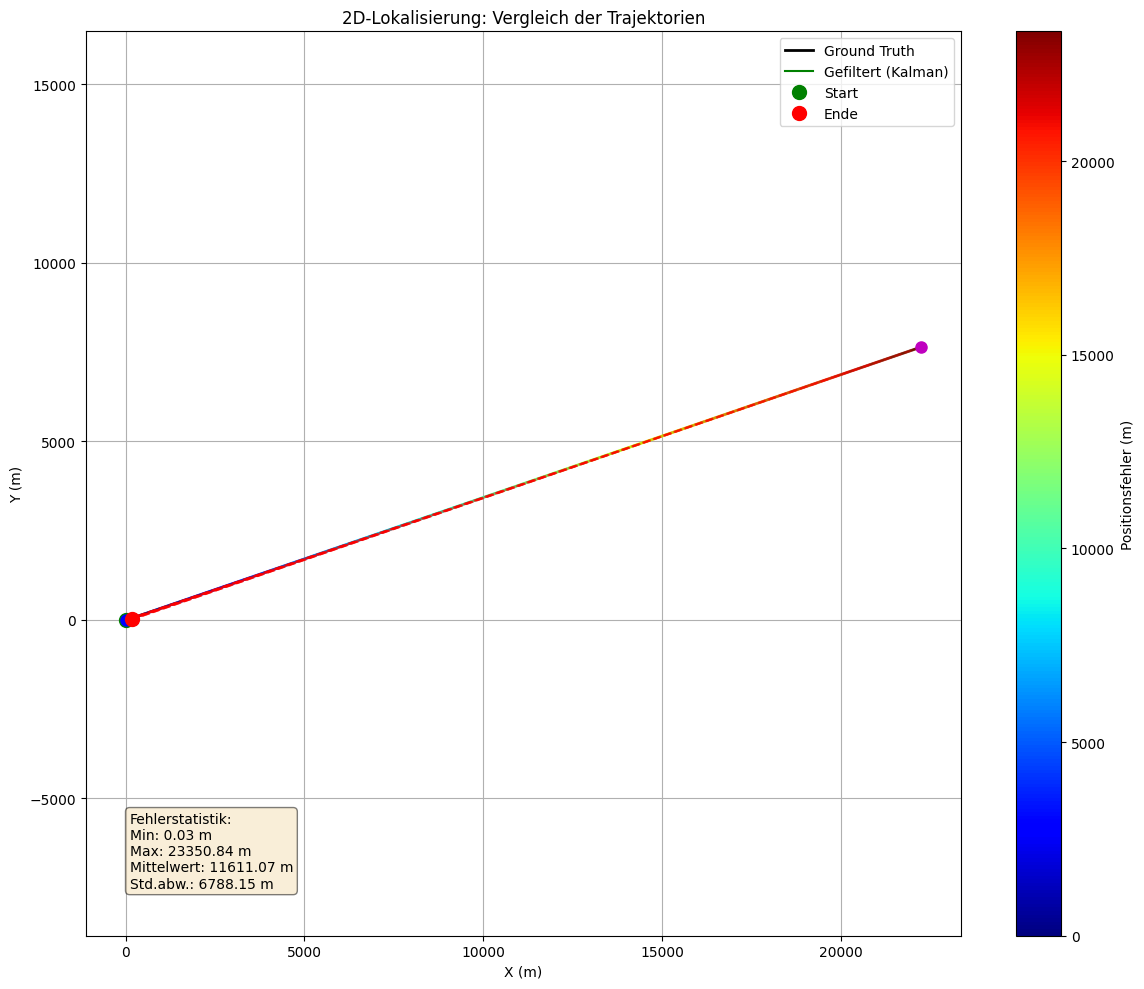


Visualisiere korrigierte Trajektorie...


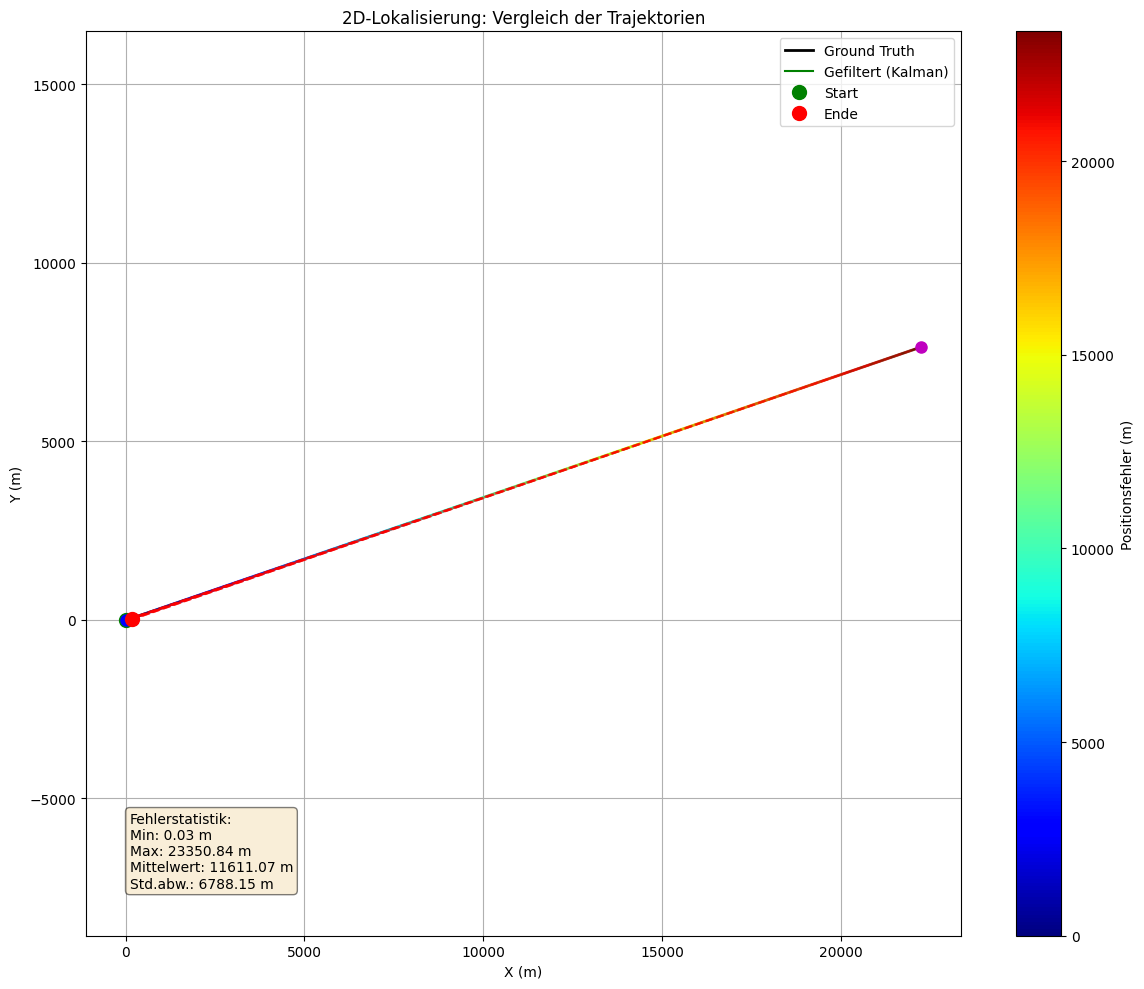

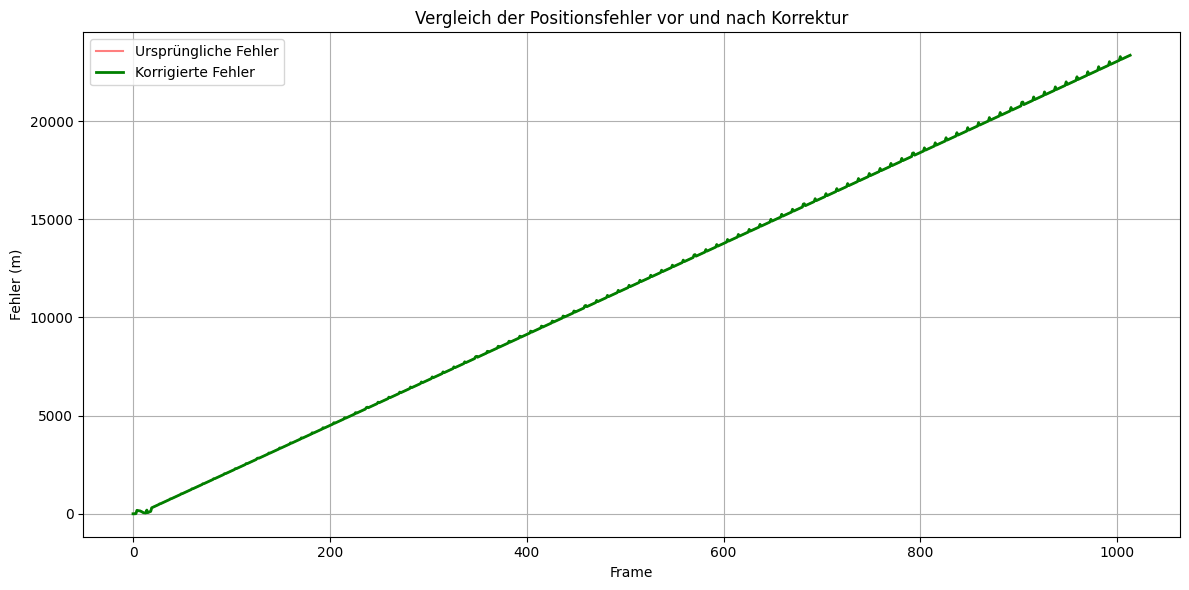


Visualisiere am stärksten verbesserte Frames: [998, 999, 0]
Size of points_2D: (9149, 2)
Size of points_2D: (574, 2)


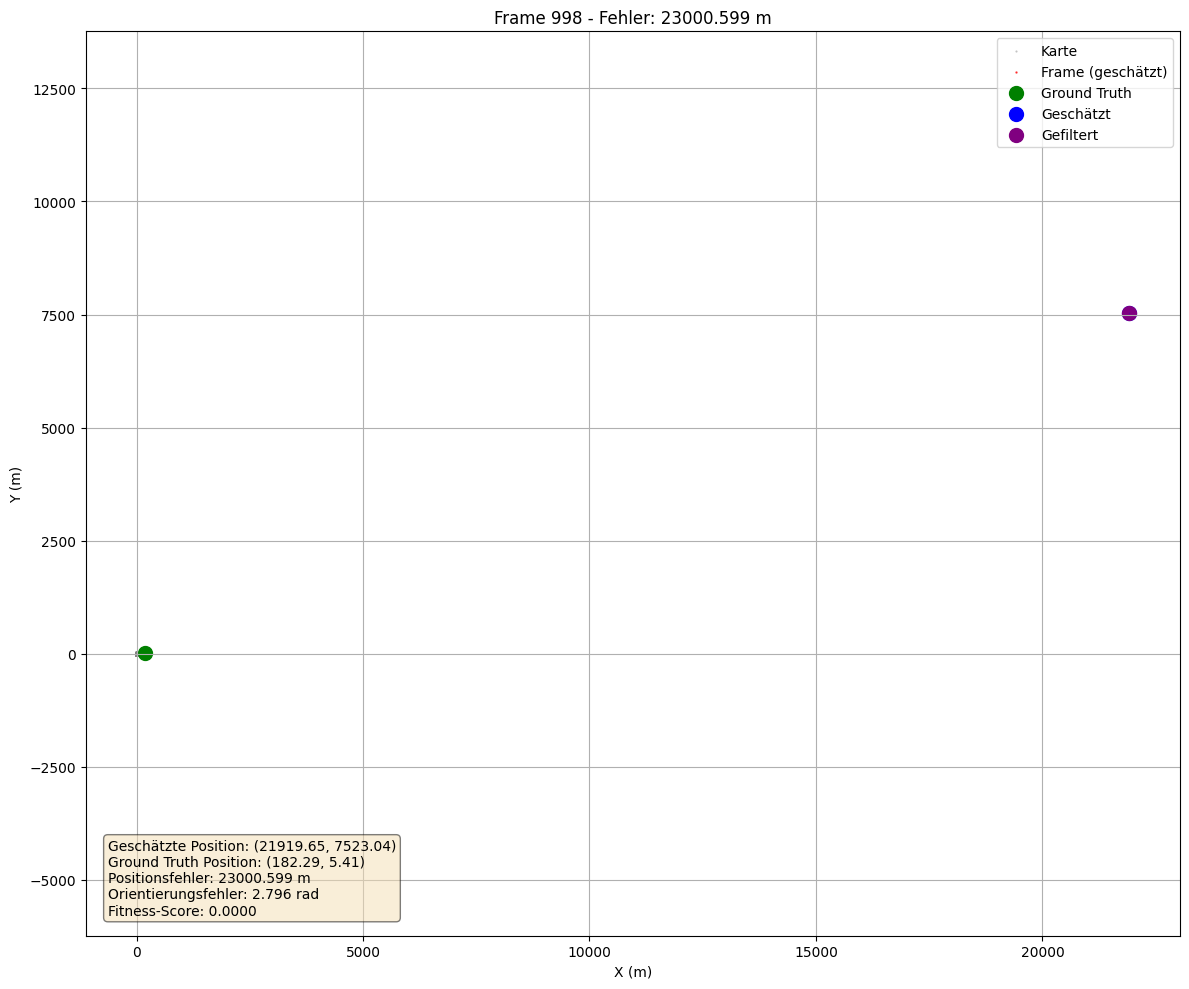

Size of points_2D: (282, 2)


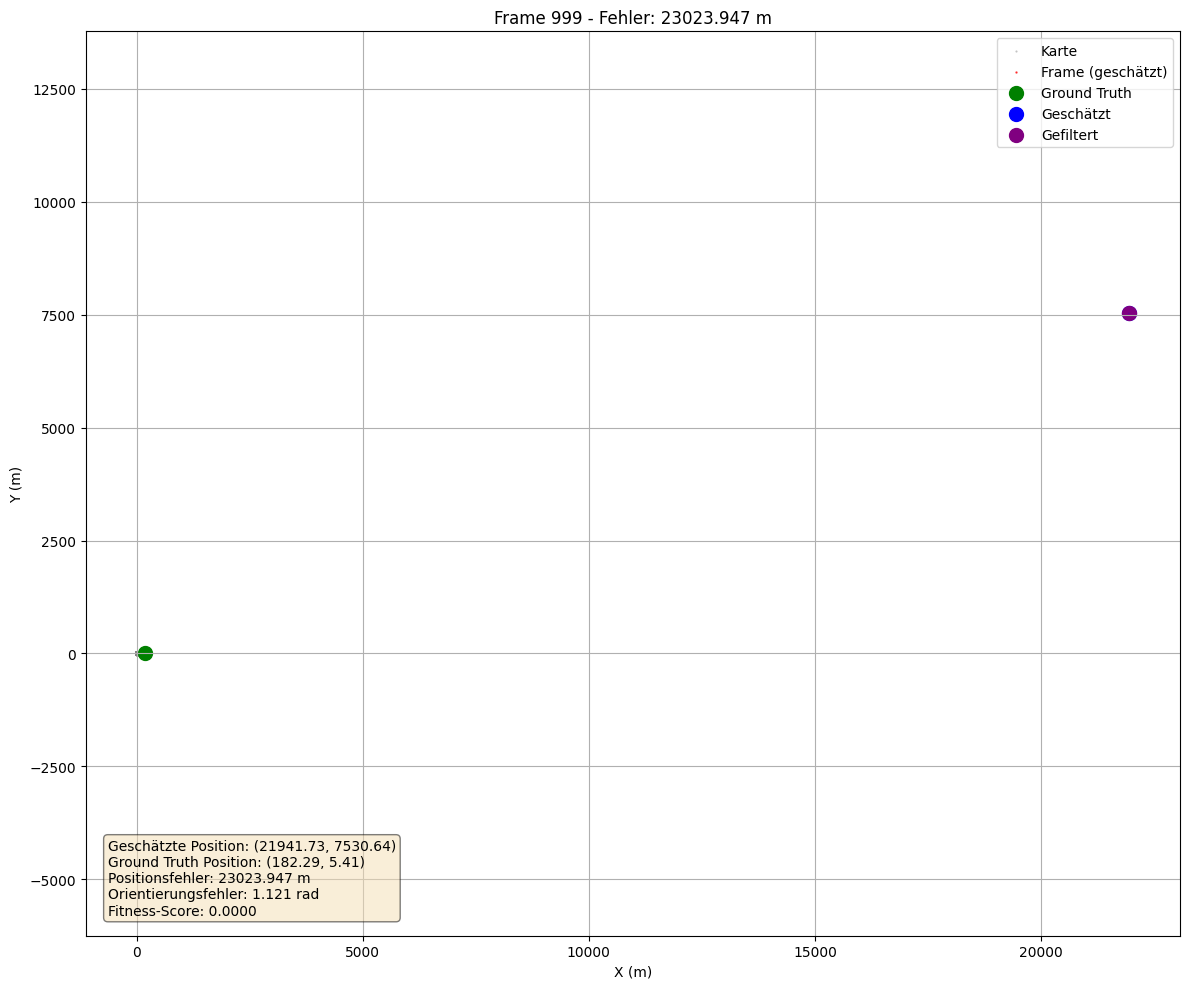

Size of points_2D: (604, 2)


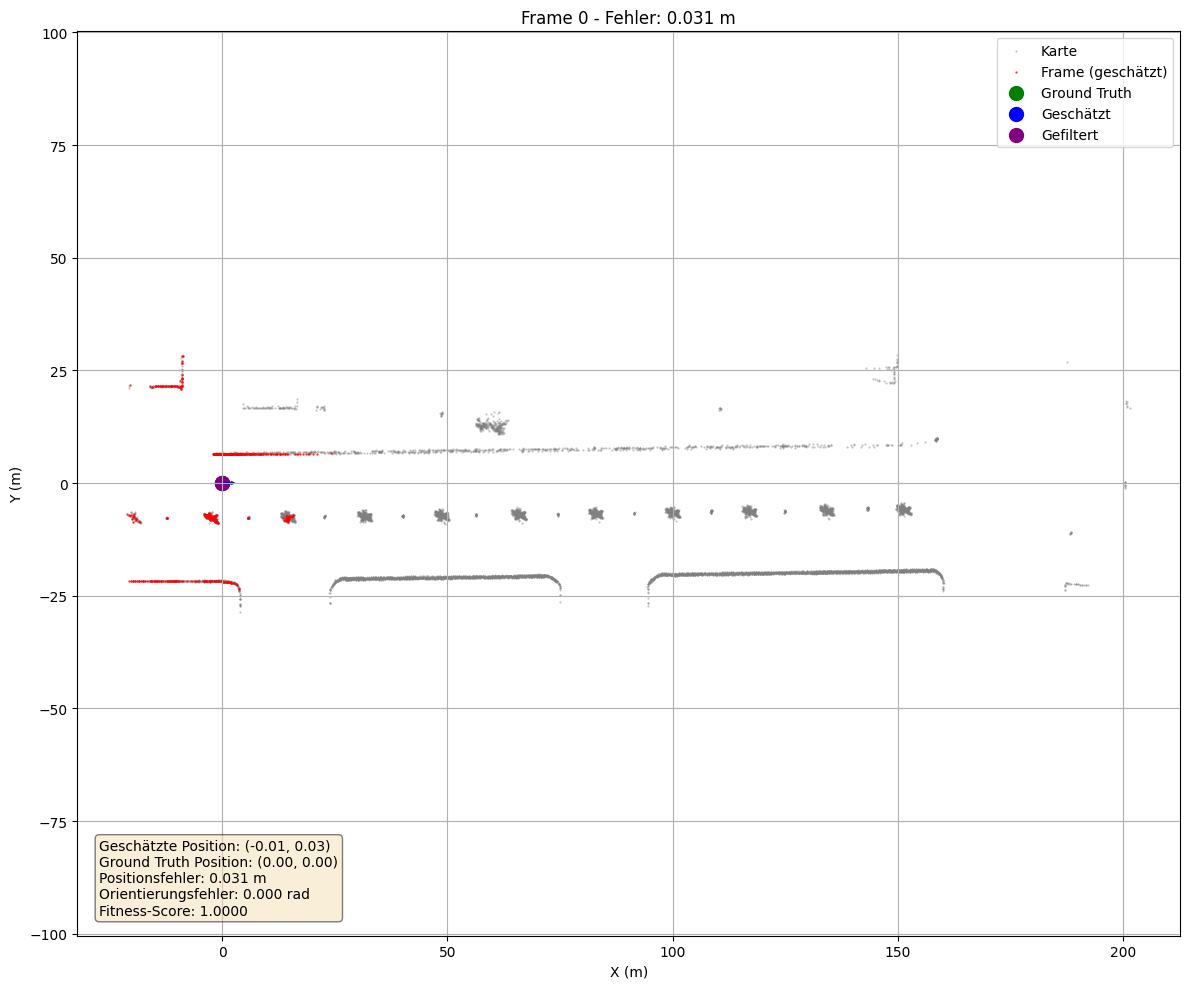


Visualisiere Schlüssel-Frames: [0, 253, 507, 760, 1013]
Size of points_2D: (9149, 2)
Size of points_2D: (604, 2)


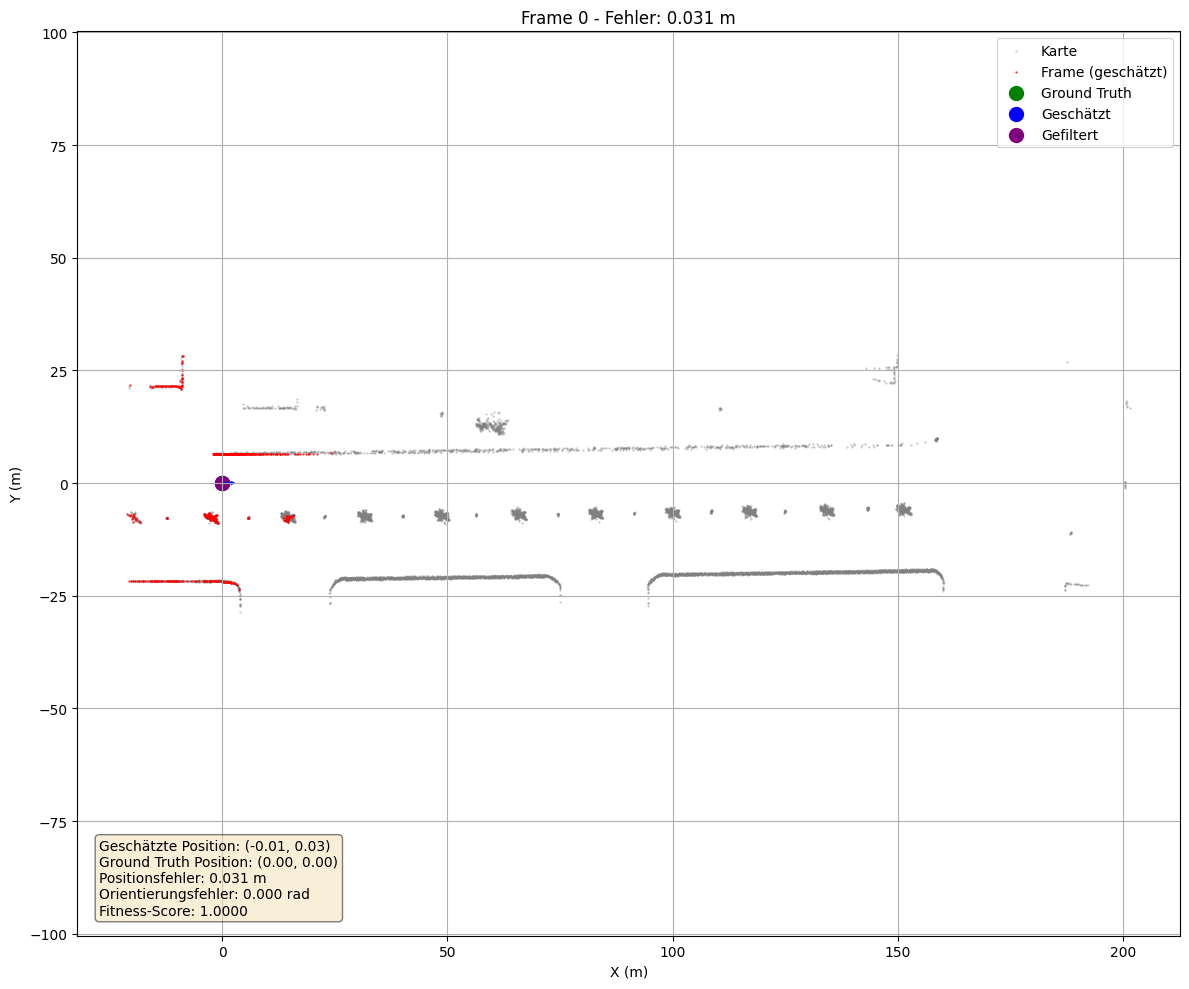

Size of points_2D: (1076, 2)


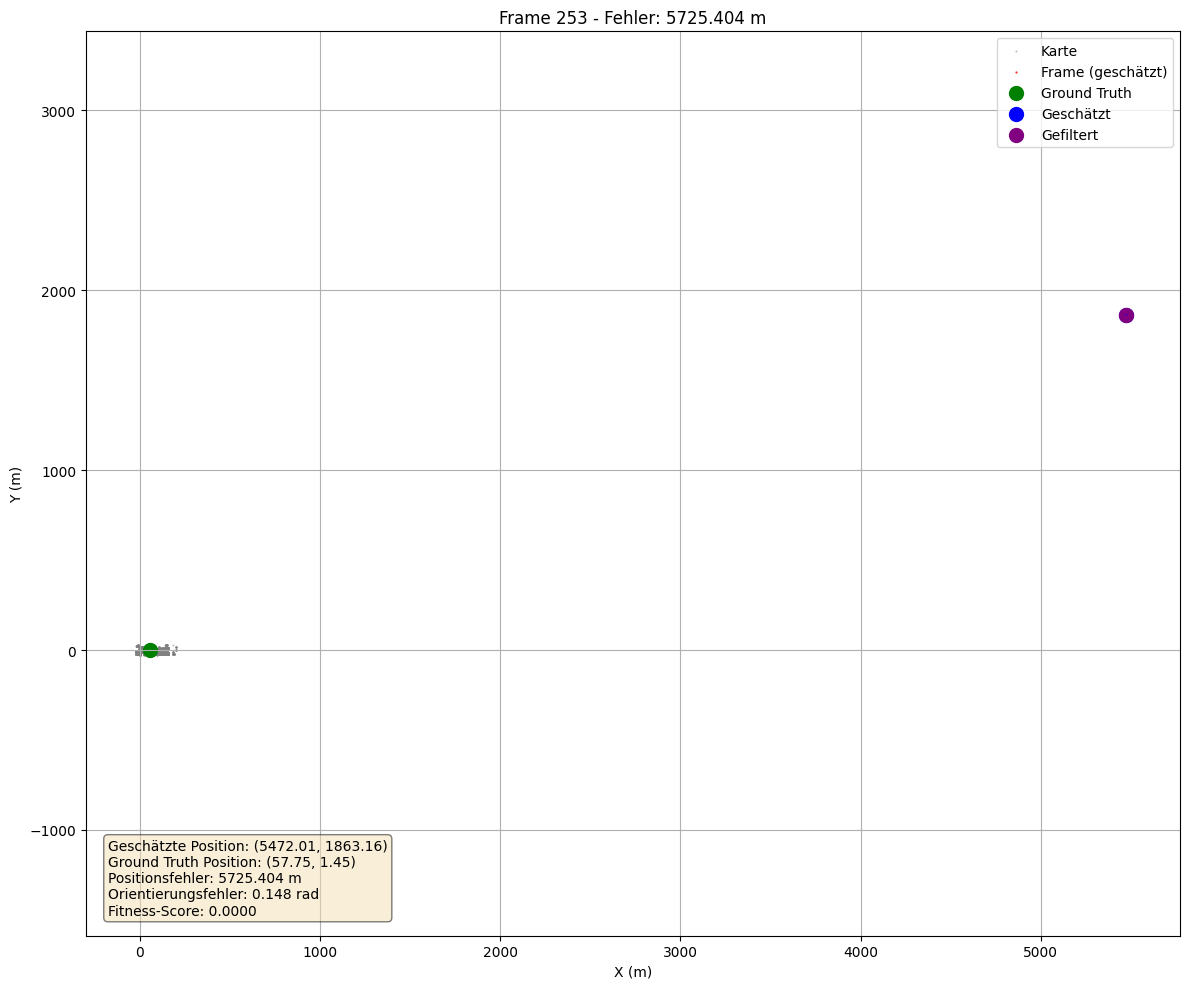

Size of points_2D: (1110, 2)


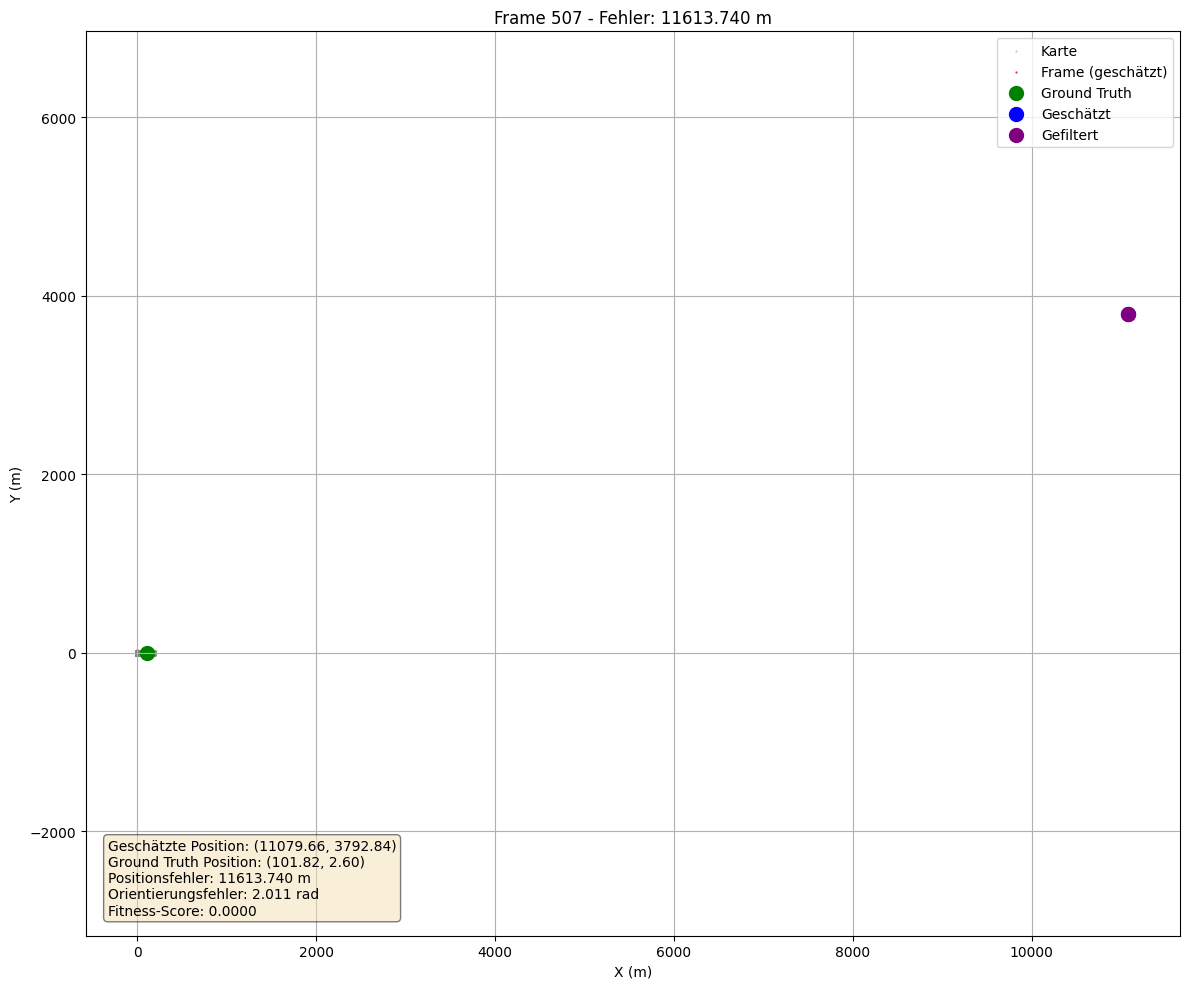

Size of points_2D: (1179, 2)


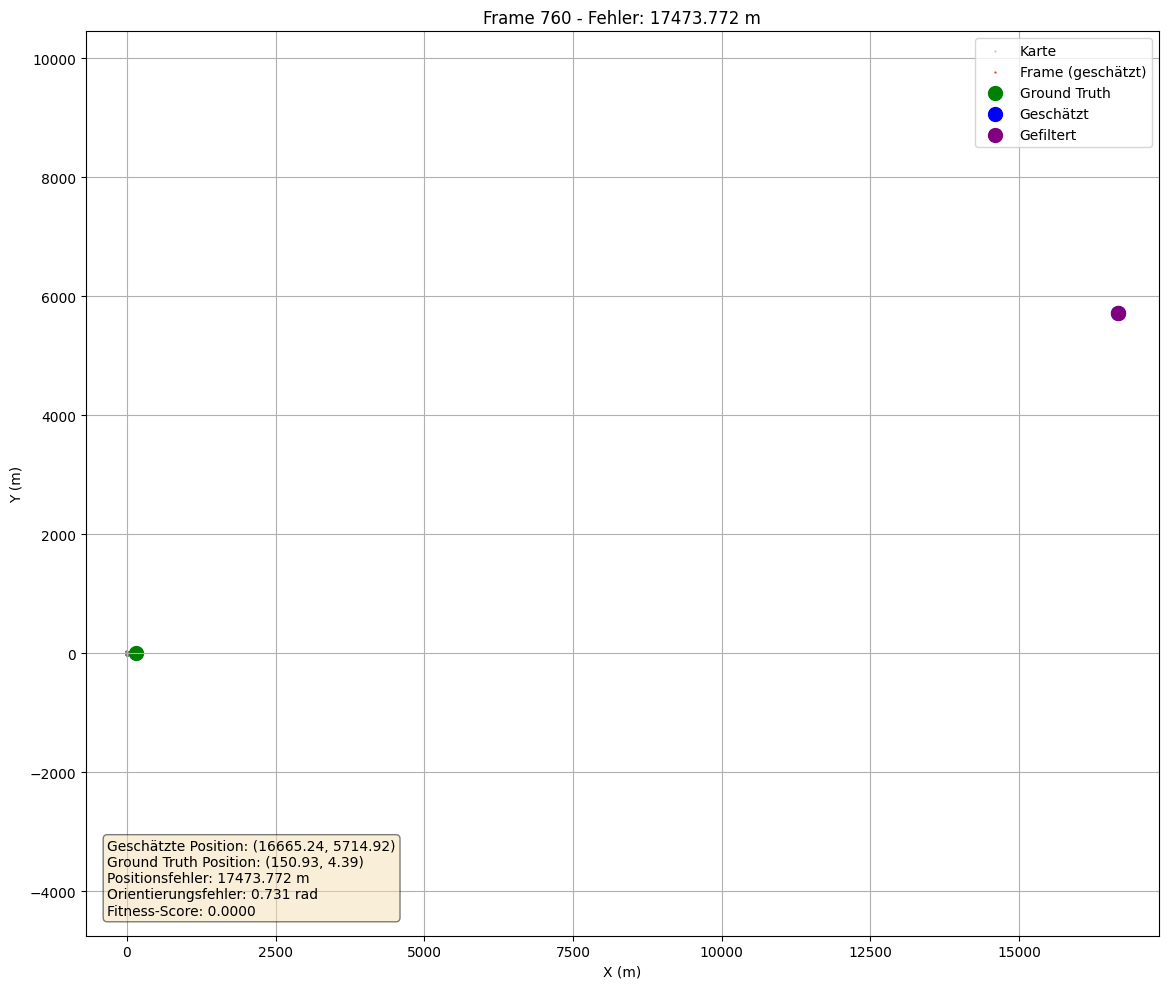

Size of points_2D: (167, 2)


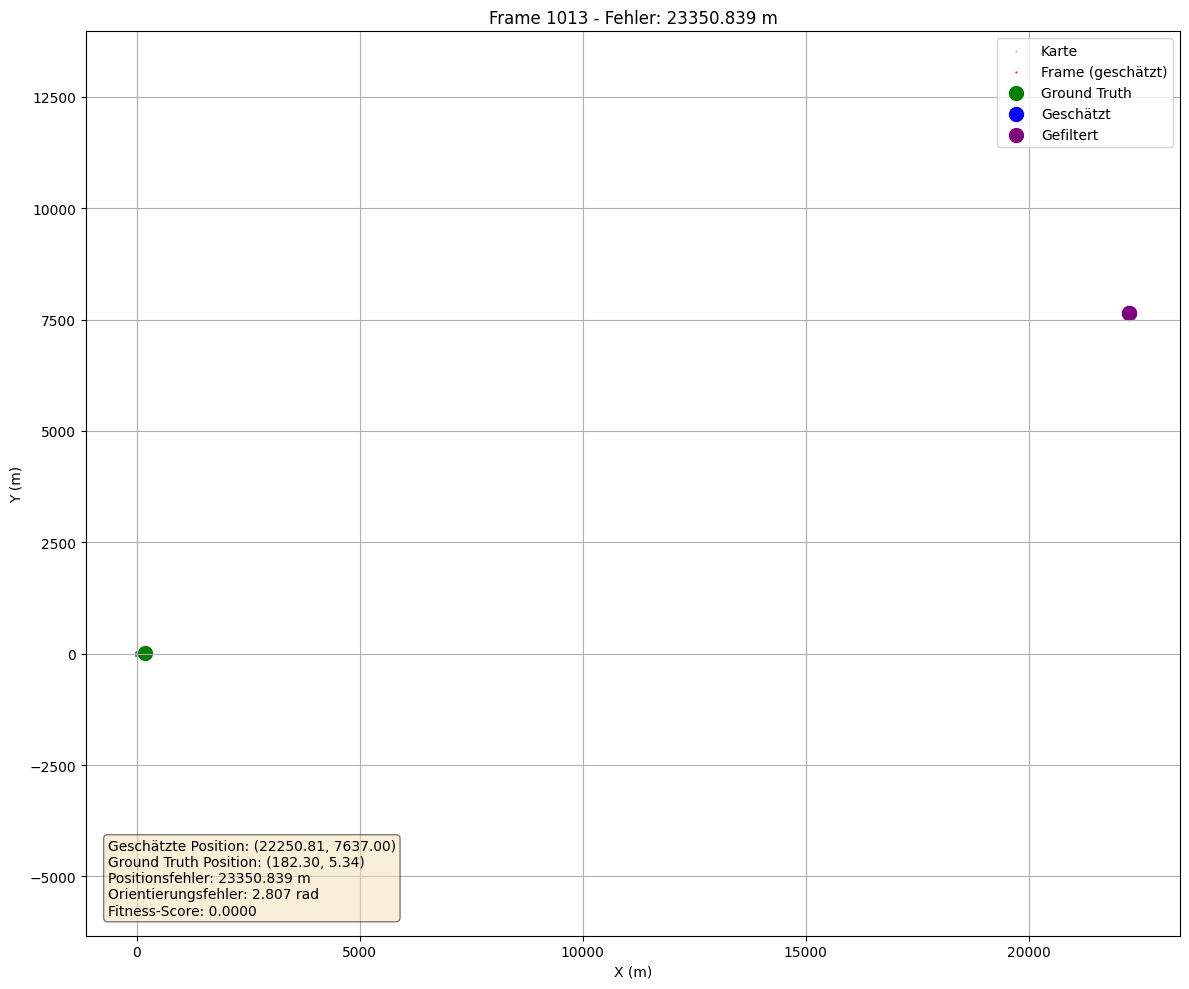

Korrigierte Ergebnisse gespeichert in localization_results_2d_corrected.npy


In [118]:
def main():
    """
    Hauptfunktion zur Ausführung der verbesserten 2D-Lokalisierung
    """
    # Pfade definieren
    map_path = "./dataset/map.pcd"
    frames_dir = "./dataset/frames"
    ground_truth_path = "./dataset/ground_truth.csv"
    
    # Prüfen, ob bereits Ergebnisse vorhanden sind
    results_path = "localization_results_2d_improved.npy"
    
    if os.path.exists(results_path):
        print(f"Lade vorhandene Ergebnisse aus {results_path}...")
        results = np.load(results_path, allow_pickle=True).tolist()
    else:
        print("Starte verbesserte 2D-Lokalisierung...")
        results = improved_localize_vehicle_2d(map_path, frames_dir, ground_truth_path)
        np.save(results_path, results)
    
    # Ausreißer erkennen und behandeln
    corrected_results = detect_and_handle_outliers(results)
    
    # Ergebnisse vor und nach der Korrektur vergleichen
    orig_errors = [r['position_error'] for r in results]
    corr_errors = [r['position_error'] for r in corrected_results]
    
    print("\n=== Fehlerstatistik vor Korrektur ===")
    print(f"Durchschnittlicher Positionsfehler: {np.mean(orig_errors):.3f} m")
    print(f"Median-Positionsfehler: {np.median(orig_errors):.3f} m")
    print(f"Maximaler Positionsfehler: {np.max(orig_errors):.3f} m")
    
    print("\n=== Fehlerstatistik nach Korrektur ===")
    print(f"Durchschnittlicher Positionsfehler: {np.mean(corr_errors):.3f} m")
    print(f"Median-Positionsfehler: {np.median(corr_errors):.3f} m")
    print(f"Maximaler Positionsfehler: {np.max(corr_errors):.3f} m")
    
    # Trajektorie visualisieren
    print("\nVisualisiere ursprüngliche Trajektorie...")
    visualize_2d_trajectory(results)
    
    print("\nVisualisiere korrigierte Trajektorie...")
    visualize_2d_trajectory(corrected_results)
    
    # Fehlervergleich visualisieren
    plt.figure(figsize=(12, 6))
    plt.plot(range(len(orig_errors)), orig_errors, 'r-', alpha=0.5, label='Ursprüngliche Fehler')
    plt.plot(range(len(corr_errors)), corr_errors, 'g-', linewidth=2, label='Korrigierte Fehler')
    plt.title('Vergleich der Positionsfehler vor und nach Korrektur')
    plt.xlabel('Frame')
    plt.ylabel('Fehler (m)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
    # Punktwolken für ausgewählte Frames visualisieren
    # Frames mit der größten Verbesserung finden
    improvement = np.array(orig_errors) - np.array(corr_errors)
    most_improved_indices = np.argsort(improvement)[-3:]
    most_improved_frames = [corrected_results[i]['frame'] for i in most_improved_indices]
    
    print("\nVisualisiere am stärksten verbesserte Frames:", most_improved_frames)
    visualize_2d_point_clouds(corrected_results, map_path, frames_dir, most_improved_frames)
    
    # Weitere Frames zur Visualisierung
    key_frames = [0, len(corrected_results)//4, len(corrected_results)//2, 3*len(corrected_results)//4, len(corrected_results)-1]
    print("\nVisualisiere Schlüssel-Frames:", key_frames)
    visualize_2d_point_clouds(corrected_results, map_path, frames_dir, key_frames)
    
    # Ergebnisse speichern
    np.save("localization_results_2d_corrected.npy", corrected_results)
    print(f"Korrigierte Ergebnisse gespeichert in localization_results_2d_corrected.npy")

if __name__ == "__main__":
    main()


In [ ]:
convert_to_2d